# Lab Day 1 — Mạng nơ-ron và thí nghiệm huấn luyện (Forest CoverType)

**Sinh viên:** Đoàn Duy Bách — **MSSV:** 2A202602515

Notebook nằm ở `submission_2A202602515/code/lab.ipynb`; ghi ảnh vào `../figures/`, kết quả vào `../results/`, đọc dữ liệu và script từ `../../` (thư mục gốc repo).
Mọi lựa chọn cấu hình (lr, kiến trúc, kỹ thuật, epoch) chỉ dựa vào **tập val** (20% của train, phân tầng, seed 42). Tập **eval** chỉ xuất hiện ở Part 4, cho baseline và cấu hình cuối cùng.

Quy ước trong notebook:
- Mỗi thí nghiệm là một dict cấu hình truyền vào **một** hàm `run_experiment` (file `train.py`); hàm trợ giúp `run(...)` bên dưới chỉ gọi nó, lưu `../results/<exp_id>.json` và vẽ `../figures/<exp_id>.png`.
- Chỉ số so sánh: **val macro-F1 ở epoch có val loss thấp nhất** (best epoch), kèm val accuracy và val loss.
- Ngưỡng nhiễu: **2σ** của val macro-F1 qua 5 seed baseline (Part 2). Chênh lệch nhỏ hơn 2σ được coi là *chưa kết luận được*.
- Mỗi thí nghiệm có **dự đoán viết trước khi chạy** và **đối chiếu viết sau khi chạy**.

In [1]:
# ===== Cấu hình đường dẫn và môi trường =====
import os, sys, json, math, time, platform, subprocess
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
%matplotlib inline

REPO_ROOT = "../.."     # thư mục gốc repo (chứa data/ và scripts/), tính từ submission_<MSSV>/code/
OUT_DIR   = ".."        # = submission_<MSSV>/ : figures/, results/, experiments.xlsx, predictions_eval.csv
# Colab: nếu chưa có repo, bỏ comment 2 dòng dưới, đặt REPO_ROOT cho đúng, và copy thư mục nộp vào repo.
# !git clone https://github.com/VinUni-AI20k/K4-Track4-Day1-Neuralnetwork.git
# REPO_ROOT = "/content/K4-Track4-Day1-Neuralnetwork"

if torch.cuda.is_available():
    device = "cuda"
    dev_name = torch.cuda.get_device_name(0)
elif torch.backends.mps.is_available():
    device = "mps"
    dev_name = f"Apple GPU (MPS) — {platform.machine()} {platform.mac_ver()[0] and 'macOS ' + platform.mac_ver()[0]}"
else:
    device = "cpu"
    dev_name = platform.processor() or "CPU"
print(f"Python {platform.python_version()} | torch {torch.__version__} | device = {device} ({dev_name})")

FIG_DIR, RES_DIR = f"{OUT_DIR}/figures", f"{OUT_DIR}/results"
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(RES_DIR, exist_ok=True)

from data import prepare_data
from model import MLP, EXPECTED_PARAMS, count_params, init_weights, activation_stats
from optimizer import build_optimizer, clip_gradients
from train import DEFAULT_CFG, set_seed, evaluate, predict, run_experiment, final_eval, compute_loss, overfit_tiny
from plots import plot_run, plot_compare, plot_lr_sensitivity, plot_activation_depth, show, SERIES, STYLE
from results_table import save_result, load_results, to_row, write_xlsx

LN7 = math.log(7)
T_NOTEBOOK = time.time()

Python 3.12.14 | torch 2.14.1 | device = mps (Apple GPU (MPS) — arm64 macOS 26.5.1)


## Part 0 — Dữ liệu
Chia sẵn bằng metadata: chạy `scripts/split_data.py` từ thư mục gốc repo (tạo `data/processed/train.npz`, `eval.npz`).
Sau đó tách validation từ train (20%, phân tầng, seed 42), chuẩn hoá 10 cột số bằng mean/std **chỉ của phần train còn lại**, và đưa toàn bộ tensor lên device một lần (không dùng `DataLoader`).

In [2]:
proc = subprocess.run([sys.executable, "scripts/split_data.py"], cwd=REPO_ROOT, capture_output=True, text=True, check=True)
print(proc.stdout)

data = prepare_data(device, val_fraction=0.2, seed=42, processed_dir=f"{REPO_ROOT}/data/processed")
assert (len(data["X_tr"]), len(data["X_val"]), len(data["X_eval"])) == (371_847, 92_962, 116_203)

# Kiểm tra chuẩn hoá: 10 cột số của X_tr phải có mean ≈ 0, std ≈ 1 (val dùng CÙNG thống kê của train nên chỉ ≈)
for name in ("X_tr", "X_val"):
    num = data[name][:, :10].cpu().numpy()
    print(f"{name}: mean 10 cột số = {num.mean(0).round(3)}\n        std            = {num.std(0).round(3)}")
binary = data["X_tr"][:, 10:].cpu().numpy()
print("44 cột nhị phân giữ nguyên:", np.unique(binary).tolist())
print("mean/std dùng để chuẩn hoá (tính trên X_tr):\n", pd.DataFrame({"mean": data["mean"], "std": data["std"]}).T.round(2).to_string())
DATA_MB = sum(t.numel() * t.element_size() for t in data.values() if torch.is_tensor(t)) / 2**20
print(f"toàn bộ tensor dữ liệu trên {device}: {DATA_MB:.0f} MB")

train: X (464809, 54) float32, y (464809,) int64, nhãn 0..6 -> data/processed/train.npz
eval : X (116203, 54) float32, y (116203,) int64, nhãn 0..6 -> data/processed/eval.npz

lớp   train(%)   eval(%)
  0    36.461    36.460
  1    48.760    48.760
  2     6.154     6.154
  3     0.473     0.472
  4     1.634     1.634
  5     2.989     2.989
  6     3.530     3.530

đoán luôn lớp đa số (lớp 1) cho accuracy trên eval = 0.4876



train full 464,809 -> X_tr (371847, 54), X_val (92962, 54); X_eval (116203, 54)
tỉ lệ lớp (%)       0      1      2      3      4      5      6
  train        36.46  48.76   6.15   0.47   1.63   2.99   3.53
  val          36.46  48.76   6.15   0.47   1.63   2.99   3.53
  eval         36.46  48.76   6.15   0.47   1.63   2.99   3.53
'luôn đoán lớp đa số' (lớp 1, chọn theo train) -> accuracy trên val = 0.4876
X_tr: mean 10 cột số = [-0. -0. -0.  0.  0.  0. -0. -0. -0. -0.]
        std            = [1.    1.    1.001 1.    1.    1.    1.    1.    1.    1.   ]
X_val: mean 10 cột số = [ 0.002  0.002 -0.002  0.    -0.     0.006 -0.004  0.002  0.005  0.004]
        std            = [0.998 1.001 0.998 1.004 0.999 1.004 1.001 1.    0.999 1.003]
44 cột nhị phân giữ nguyên: [0.0, 1.0]
mean/std dùng để chuẩn hoá (tính trên X_tr):
                 0           1      2           3          4            5           6           7           8            9
mean  2959.379883  155.779999  14.11  269.329987

**Nhận xét Part 0:** kích thước khớp GUIDE (371 847 train / 92 962 val / 116 203 eval); tỉ lệ 7 lớp ở ba tập gần như trùng nhau nhờ phân tầng. Mốc thấp nhất cần vượt: "luôn đoán lớp 1" cho accuracy **0,4876** trên val. Thống kê chuẩn hoá chỉ tính trên `X_tr`: nếu tính cả trên val/eval thì thông tin của dữ liệu dùng để đánh giá rò vào tiền xử lý (rò rỉ), điểm val/eval sẽ lạc quan hơn thực tế. `X_eval` chỉ được *áp* mean/std của train, không đi vào bất kỳ bước chọn lựa nào trước Part 4.

## Part 1 — Model và kiểm tra "sức khoẻ" ban đầu
Quy định: `M-base` = `54 → 256 → 128 → 7`, **47 879 tham số**, logits `(B, 7)`, không softmax trong model. Baseline khởi tạo **He** (`kaiming_normal_`, fan_in, bias = 0), gọi tường minh trong `model.init_weights`; không dùng mặc định của `nn.Linear`.

In [3]:
# 1a-1b. Model, số tham số, shape qua từng lớp
set_seed(0)
model = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device)
n_params = count_params(model)
assert n_params == EXPECTED_PARAMS[(256, 128)] == 47_879
print(model)
print("số tham số:", n_params)

xb = torch.randn(8, 54, device=device)
h = xb
print(f"{'input':<8s} -> {tuple(h.shape)}")
for layer in model.net:
    h = layer(h)
    print(f"{layer.__class__.__name__:<8s} -> {tuple(h.shape)}")
logits = model(xb)
assert logits.shape == (8, 7) and logits.dtype == torch.float32
print("std của W theo lớp:", [round(m.weight.std().item(), 4) for m in model.net if isinstance(m, torch.nn.Linear)],
      "| He kỳ vọng sqrt(2/n_in) =", [round(math.sqrt(2 / n), 4) for n in (54, 256, 128)])

MLP(
  (net): Sequential(
    (0): Linear(in_features=54, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=7, bias=True)
  )
)
số tham số: 47879
input    -> (8, 54)


Linear   -> (8, 256)
ReLU     -> (8, 256)
Linear   -> (8, 128)
ReLU     -> (8, 128)
Linear   -> (8, 7)


std của W theo lớp: [0.1936, 0.0885, 0.1246] | He kỳ vọng sqrt(2/n_in) = [0.1925, 0.0884, 0.125]


In [4]:
# 1c-1. Loss bước 0 trên val (eval mode)
ev0 = evaluate(model, data["X_val"], data["y_val"])
with torch.no_grad():
    z = model(data["X_val"][:8192])
print(f"loss bước 0 trên val = {ev0['loss']:.4f}   (ln 7 = {LN7:.4f}, lệch {ev0['loss'] - LN7:+.4f})")
print(f"std của logit ở bước 0 = {z.std().item():.3f}")

# Đối chứng: cùng model nhưng W của lớp cuối = 0 -> mọi logit = 0 -> softmax đều -> loss phải đúng bằng ln 7
with torch.no_grad():
    m0 = MLP(hidden=(256, 128), init="he").to(device)
    m0.net[-1].weight.zero_()
print(f"đối chứng W3 = 0: loss bước 0 = {evaluate(m0, data['X_val'], data['y_val'])['loss']:.4f}")

loss bước 0 trên val = 2.2073   (ln 7 = 1.9459, lệch +0.2614)


std của logit ở bước 0 = 0.603
đối chứng W3 = 0: loss bước 0 = 1.9459


quá khớp 20 mẫu: loss 2.1983 -> 0.000000 sau 500 bước; accuracy trên 20 mẫu = 1.00


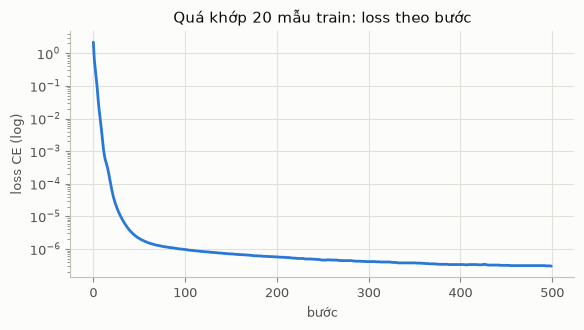

In [5]:
# 1c-2. Quá khớp 20 mẫu (dropout tắt, Adam lr=1e-2, 500 bước): loss phải về gần 0
curve = overfit_tiny(data, n=20, steps=500, lr=1e-2)
with plt.rc_context(STYLE):
    fig, ax = plt.subplots(figsize=(6.5, 3.2))
    ax.semilogy(curve, color=SERIES[0])
    ax.set(xlabel="bước", ylabel="loss CE (log)", title="Quá khớp 20 mẫu train: loss theo bước")
    plt.show()
assert curve[-1] < 1e-2

In [6]:
# 1d. Gradient có chảy tới mọi tham số không? (một lô train, một lần backward)
model.train()
model.zero_grad(set_to_none=True)
loss = compute_loss(model(data["X_tr"][:512]), data["y_tr"][:512], "ce")
loss.backward()
for short, (name, p) in zip(["W1", "b1", "W2", "b2", "W3", "b3"], model.named_parameters()):
    g = p.grad
    assert g is not None and g.norm().item() > 0, f"{short} không có gradient"
    print(f"{short} ({name:<12s} {str(tuple(p.shape)):<10s}) ‖grad‖ = {g.norm().item():.4e}")

W1 (net.0.weight (256, 54) ) ‖grad‖ = 4.5429e-01
b1 (net.0.bias   (256,)    ) ‖grad‖ = 2.6839e-01
W2 (net.2.weight (128, 256)) ‖grad‖ = 1.7565e+00
b2 (net.2.bias   (128,)    ) ‖grad‖ = 3.8244e-01
W3 (net.4.weight (7, 128)  ) ‖grad‖ = 1.9387e+00
b3 (net.4.bias   (7,)      ) ‖grad‖ = 5.4980e-01


**Nhận xét Part 1:** model đúng 47 879 tham số, logits `(8, 7)`; std của W khớp He (0,194 / 0,089 / 0,125 so với √(2/n_vào) = 0,193 / 0,088 / 0,125), tức He được áp dụng thật chứ không phải mặc định của `nn.Linear`.
- **Loss bước 0 = 2,207** (seed 0; các lần chạy seed 1 đo 2,269), cao hơn ln 7 = 1,946 khoảng 0,26–0,32. Đây không phải lỗi: He nhân phương sai với 2 để bù ReLU, nhưng lớp cuối không có ReLU phía sau, nên logit có std ≈ 0,60 thay vì ≈ 0. Với logit ngẫu nhiên std σ, loss kỳ vọng ≈ ln 7 + σ²/2·(1 − 1/7) ≈ 1,946 + 0,15 + phần tương quan. Đối chứng: đặt W3 = 0 cho loss **đúng 1,9459**. Bảng 3.7 cũng cho thấy init cho logit nhỏ (normal, zeros) có loss bước 0 = 1,946. Độ lệch nhỏ so với ngưỡng "lệch nhiều" của bảng triệu chứng, và biến mất sau vài chục bước.
- **Quá khớp 20 mẫu:** loss 2,198 → < 1e-6 sau 500 bước, accuracy 100% trên 20 mẫu, nên đường forward/backward/optimizer không có lỗi kiểu nhãn lệch, softmax hai lần hay quên `zero_grad`.
- **Gradient chảy:** cả 6 tham số W1…b3 có ‖grad‖ khác 0 (0,27 → 1,94).

## Part 2 — Pipeline và baseline
`run_experiment(cfg, data)` (file `train.py`) nhận một dict cấu hình, huấn luyện và trả về lịch sử + tóm tắt. Mỗi epoch ghi: train loss **đo ở eval mode trên toàn bộ train**, val loss/accuracy/macro-F1, chuẩn gradient toàn cục **trước khi clip** (trung bình, lớn nhất, và 1/10 số bước để thấy gai), tỉ lệ bước bị clip, thời gian huấn luyện của epoch (có `synchronize`), bộ nhớ cực đại; cộng loss bước 0 và cờ `diverged` (dừng sớm nếu loss NaN/inf). Best epoch = epoch có val loss thấp nhất; metric báo cáo lấy ở epoch đó (giống dừng sớm) và `best_state` được giữ lại để dự đoán eval.

Ghi chú đo đạc trên máy này (Apple MPS): `time_per_epoch_s` là trung bình **từ epoch 2** (epoch 1 gồm chi phí biên dịch kernel lần đầu); MPS không có `max_memory_allocated` nên `peak_mem_MB` là giá trị lớn nhất của `torch.mps.current_allocated_memory()` lấy mẫu sau forward ở 5 bước đầu, và **gồm cả toàn bộ dữ liệu** đã nằm sẵn trên GPU (`DATA_MB`, in ở Part 0); cột phụ `peak_mem_train_MB` trong JSON là phần tăng thêm do huấn luyện.

In [7]:
RESULTS = {}   # exp_id -> result (có best_state, giữ trong RAM để dự đoán eval ở Part 4)

def run(exp_id, group, description, base=None, verbose=False, **changes):
    # Một thí nghiệm = base cfg + các thay đổi; lưu JSON + ảnh; in một dòng tóm tắt.
    cfg = {**(base or BASE_CFG), "exp_id": exp_id, "group": group, "description": description, **changes}
    r = run_experiment(cfg, data, verbose=verbose)
    save_result(r, RES_DIR)
    plot_run(r, f"{FIG_DIR}/{exp_id}.png")
    RESULTS[exp_id] = r
    s = r["summary"]
    print(f"{exp_id:<26s} best ep {str(s['best_epoch']):>3s}/{cfg['epochs']:<3d} val_loss {s['best_val_loss']:.4f}  "
          f"acc {s['val_acc']:.4f}  F1 {s['val_macro_f1']:.4f}  |g| {np.nanmean(r['history']['grad_norm']):.3f}  "
          f"{s['time_per_epoch_s']:.2f}s/ep" + ("  DIVERGED" if s["diverged"] else ""))
    return r

def table(ids, ref=True):
    # Bảng so sánh trên VAL; ΔF1 so với trung bình 5 seed baseline, 'vượt 2σ?' so với ngưỡng nhiễu.
    rows = []
    for e in ids:
        c, s = RESULTS[e]["cfg"], RESULTS[e]["summary"]
        row = dict(exp_id=e, best_ep=s["best_epoch"], step0=s["step0_loss"], best_val_loss=s["best_val_loss"],
                   gap_val_train=s["final_val_loss"] - s["final_train_loss"],
                   val_acc=s["val_acc"], val_F1=s["val_macro_f1"], s_per_ep=s["time_per_epoch_s"],
                   diverged=s["diverged"])
        if ref and "NOISE_F1" in globals():
            row["ΔF1_vs_base"] = s["val_macro_f1"] - BASE_F1_MEAN
            row["vượt 2σ?"] = "Có" if abs(row["ΔF1_vs_base"]) > NOISE_F1 else "Không"
        rows.append(row)
    return pd.DataFrame(rows).set_index("exp_id").round(4)

def f1(e):
    return RESULTS[e]["summary"]["val_macro_f1"]

### 2a. Chọn lr cho baseline (SGD + momentum 0,9) bằng val
**Dự đoán trước:** với đầu vào đã chuẩn hoá và khởi tạo He, momentum 0,9 khuếch đại bước khoảng 1/(1−0,9) = 10 lần, nên lr hiệu dụng của lr = 0,1 là ~1. Mình đoán lr = 0,01 quá chậm trong 20 epoch (đường loss còn dốc ở cuối), 0,03–0,1 tốt nhất, 0,3 bắt đầu dao động. Vì GUIDE nói các cấu hình 20 epoch "chưa hội tụ hẳn", lr lớn nhất mà còn ổn định sẽ thắng.

*(Bổ sung sau lần chạy đầu, chưa chạm eval: lưới ban đầu 0,01–0,3 cho lr tốt nhất ở mép 0,3, nên thêm lr = 1 để chắc lr được chọn không bị chặn bởi lưới.)*

opt-sgdm-lr0.01            best ep  19/20  val_loss 0.3162  acc 0.8721  F1 0.7644  |g| 1.056  0.32s/ep


opt-sgdm-lr0.03            best ep  20/20  val_loss 0.2573  acc 0.8961  F1 0.8280  |g| 0.942  0.32s/ep


opt-sgdm-lr0.1             best ep  20/20  val_loss 0.2332  acc 0.9087  F1 0.8504  |g| 0.568  0.31s/ep


opt-sgdm-lr0.3             best ep  20/20  val_loss 0.2261  acc 0.9098  F1 0.8571  |g| 0.357  0.31s/ep


opt-sgdm-lr1               best ep  20/20  val_loss 0.3541  acc 0.8612  F1 0.7731  |g| 0.252  0.32s/ep

=> lr baseline = 0.3


,best_ep,step0,best_val_loss,gap_val_train,val_acc,val_F1,s_per_ep,diverged
exp_id,,,,,,,,
opt-sgdm-lr0.01,19,2.2691,0.3162,0.0106,0.8721,0.7644,0.3215,False
opt-sgdm-lr0.03,20,2.2691,0.2573,0.0166,0.8961,0.8280,0.3154,False
opt-sgdm-lr0.1,20,2.2691,0.2332,0.0234,0.9087,0.8504,0.3102,False
opt-sgdm-lr0.3,20,2.2691,0.2261,0.0250,0.9098,0.8571,0.3103,False
opt-sgdm-lr1,20,2.2691,0.3541,0.0134,0.8612,0.7731,0.3158,False


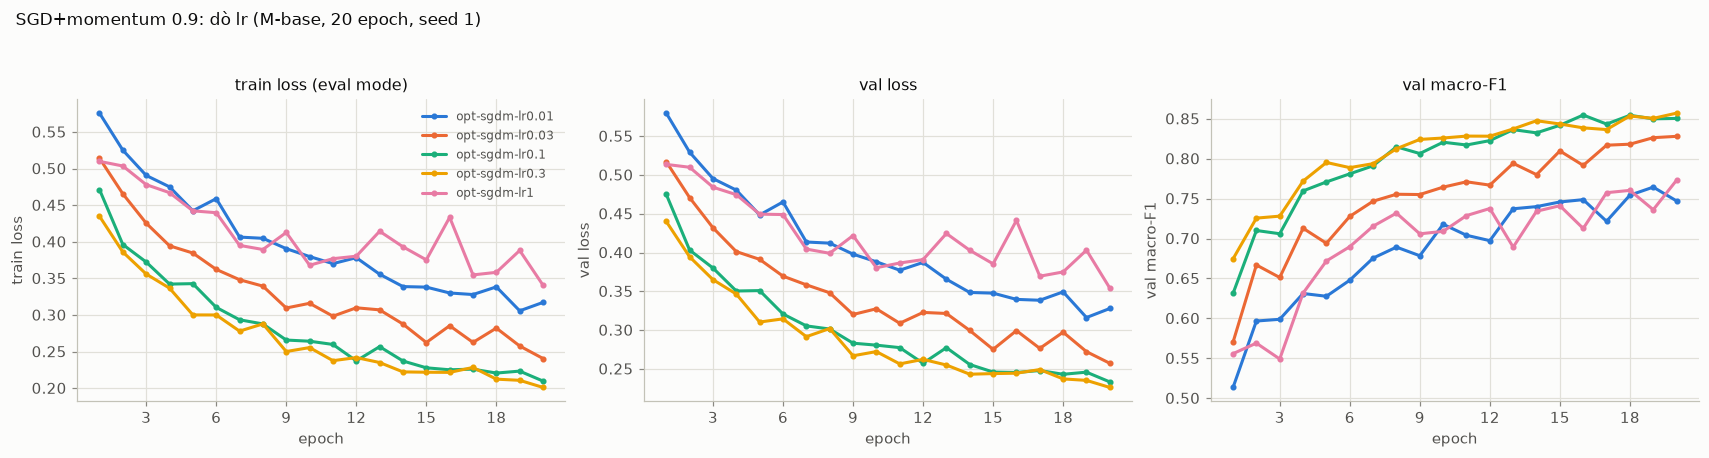

In [8]:
SWEEP_SGDM = [0.01, 0.03, 0.1, 0.3, 1.0]   # 1.0 bổ sung sau lần chạy đầu: 0.3 nằm ở mép lưới
for lr in SWEEP_SGDM:
    run(f"opt-sgdm-lr{lr:g}", "optimizer", f"SGD+momentum 0.9, lr={lr:g} (dò lr cho baseline)", base=DEFAULT_CFG, lr=lr,
        notes="dò lr cho baseline")

# Chọn lr có val macro-F1 (ở best epoch) cao nhất — chỉ số chính, chỉ trên val
BASE_LR = max(SWEEP_SGDM, key=lambda lr: f1(f"opt-sgdm-lr{lr:g}"))
BASE_CFG = {**DEFAULT_CFG, "lr": BASE_LR}
print(f"\n=> lr baseline = {BASE_LR:g}")
display(table([f"opt-sgdm-lr{lr:g}" for lr in SWEEP_SGDM], ref=False))
plot_compare([RESULTS[f"opt-sgdm-lr{lr:g}"] for lr in SWEEP_SGDM], ["train_loss", "val_loss", "val_macro_f1"],
             f"{FIG_DIR}/compare_optimizer_sgdm_lr.png", title="SGD+momentum 0.9: dò lr (M-base, 20 epoch, seed 1)")
show(f"{FIG_DIR}/compare_optimizer_sgdm_lr.png")

### 2b. Baseline với 5 seed (đo độ nhiễu)
Baseline: `M-base`, He, CE, SGD+momentum 0,9, lr chọn ở trên, batch 512, 20 epoch, dropout 0, không clip, FP32. Seed đổi cả khởi tạo lẫn thứ tự lô; phép tách val giữ nguyên (seed 42).

  [base-s1] ep  1  train 0.4349  val 0.4400  acc 0.8091  F1 0.6746  |g| 0.397  0.3s


  [base-s1] ep  2  train 0.3861  val 0.3945  acc 0.8371  F1 0.7256  |g| 0.373  0.3s


  [base-s1] ep  3  train 0.3560  val 0.3651  acc 0.8482  F1 0.7281  |g| 0.374  0.3s


  [base-s1] ep  4  train 0.3368  val 0.3465  acc 0.8558  F1 0.7719  |g| 0.370  0.3s


  [base-s1] ep  5  train 0.3002  val 0.3104  acc 0.8702  F1 0.7953  |g| 0.365  0.3s


...

base-s3                    best ep  20/20  val_loss 0.2183  acc 0.9144  F1 0.8677  |g| 0.347  0.31s/ep


base-s4                    best ep  19/20  val_loss 0.2220  acc 0.9110  F1 0.8547  |g| 0.352  0.31s/ep


base-s5                    best ep  20/20  val_loss 0.2267  acc 0.9105  F1 0.8455  |g| 0.346  0.31s/ep
base-s1 trùng khớp từng epoch với opt-sgdm-lr0.3: True


,best_ep,step0,best_val_loss,gap_val_train,val_acc,val_F1,s_per_ep,diverged
exp_id,,,,,,,,
base-s1,20,2.2691,0.2261,0.0250,0.9098,0.8571,0.3090,False
base-s2,20,1.9782,0.2107,0.0236,0.9156,0.8704,0.3087,False
base-s3,20,1.9005,0.2183,0.0255,0.9144,0.8677,0.3075,False
base-s4,19,2.3106,0.2220,0.0251,0.9110,0.8547,0.3072,False
base-s5,20,2.1444,0.2267,0.0245,0.9105,0.8455,0.3127,False


val macro-F1 = 0.8591 ± 0.0101  -> ngưỡng nhiễu 2σ = 0.0202
val accuracy = 0.9123 ± 0.0026   (mốc 'đoán đa số' = 0.4876)
best val loss = 0.2208 ± 0.0066


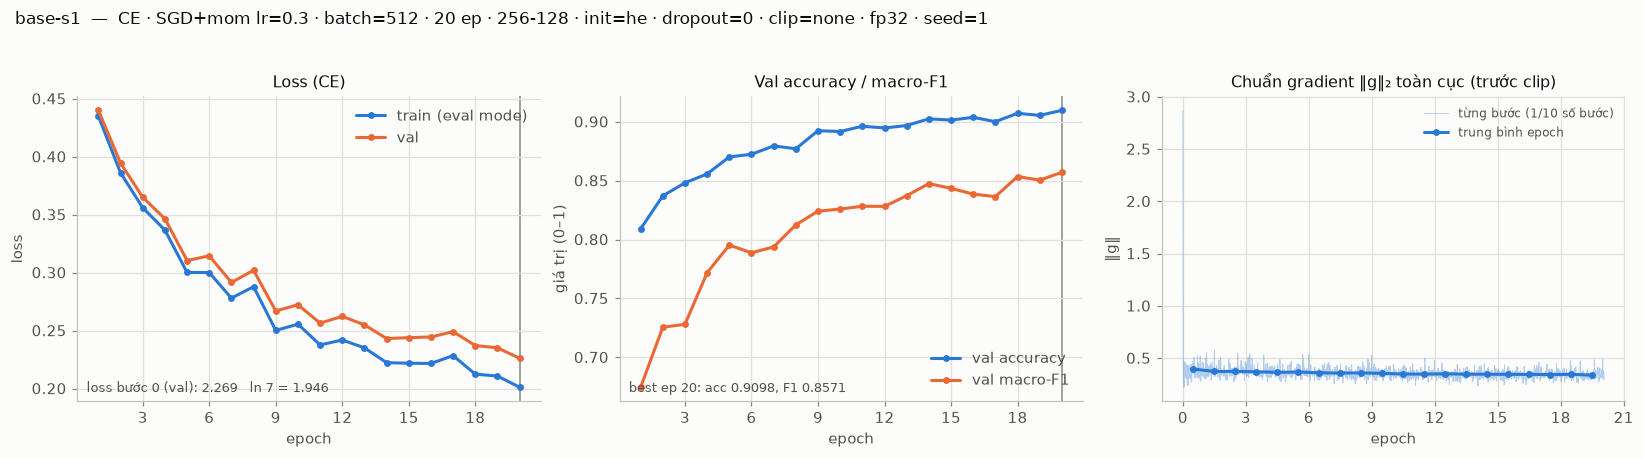

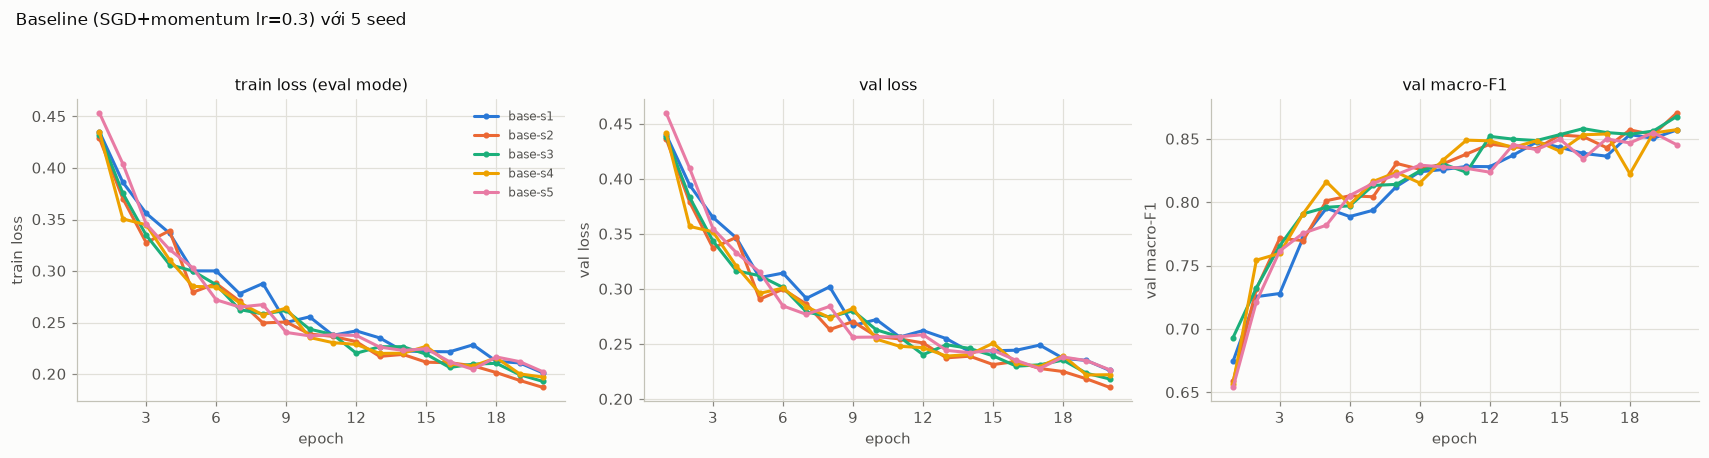

In [9]:
SEEDS = [1, 2, 3, 4, 5]
for s in SEEDS:
    run(f"base-s{s}", "baseline", f"Baseline M-base, seed {s}", seed=s, verbose=(s == 1),
        notes=f"trùng cấu hình với opt-sgdm-lr{BASE_LR:g} (seed 1)" if s == 1 else "")
base_ids = [f"base-s{s}" for s in SEEDS]

# Tất định: base-s1 và lần dò lr cùng cấu hình/seed phải cho cùng kết quả
same = RESULTS["base-s1"]["history"]["val_loss"] == RESULTS[f"opt-sgdm-lr{BASE_LR:g}"]["history"]["val_loss"]
print("base-s1 trùng khớp từng epoch với opt-sgdm-lr%g:" % BASE_LR, same)

B = table(base_ids, ref=False)
BASE_F1_MEAN, BASE_F1_STD = B["val_F1"].mean(), B["val_F1"].std(ddof=1)   # σ mẫu, giống STDEV của Excel
BASE_ACC_MEAN, BASE_ACC_STD = B["val_acc"].mean(), B["val_acc"].std(ddof=1)
NOISE_F1 = 2 * BASE_F1_STD
display(B)
print(f"val macro-F1 = {BASE_F1_MEAN:.4f} ± {BASE_F1_STD:.4f}  -> ngưỡng nhiễu 2σ = {NOISE_F1:.4f}")
print(f"val accuracy = {BASE_ACC_MEAN:.4f} ± {BASE_ACC_STD:.4f}   (mốc 'đoán đa số' = 0.4876)")
print(f"best val loss = {B['best_val_loss'].mean():.4f} ± {B['best_val_loss'].std(ddof=1):.4f}")
plot_compare([RESULTS[e] for e in base_ids], ["train_loss", "val_loss", "val_macro_f1"],
             f"{FIG_DIR}/compare_baseline.png", title=f"Baseline (SGD+momentum lr={BASE_LR:g}) với 5 seed")
show(f"{FIG_DIR}/base-s1.png")
show(f"{FIG_DIR}/compare_baseline.png")

**Nhận xét baseline:** dò lr cho SGD+momentum: F1 tăng đều từ lr 0,01 (0,764) → 0,3 (0,857) rồi tụt ở lr 1 (0,773), nên **lr = 0,3** nằm trong lưới, không phải ở mép. Dự đoán "0,03–0,1 tốt nhất, 0,3 bắt đầu dao động" **sai một nấc**: 0,3 vẫn ổn định; tới lr = 1 mới quá cao. Phần đúng của dự đoán là lr lớn nhất còn ổn định thắng, vì 20 epoch chưa đủ để hội tụ.
- Đường cong `base-s1`: train và val loss cùng giảm, còn dốc ở cuối (best epoch = 20 ở 4/5 seed, epoch 19 ở seed 4), có răng cưa nhỏ do lr hằng 0,3 khá lớn. Khoảng cách val − train chỉ **0,025** (0,201 so với 0,226), nên mô hình **chưa khớp hết, chưa quá khớp**: còn lợi khi huấn luyện lâu hơn hoặc giảm lr ở cuối.
- 5 seed: **val macro-F1 = 0,8591 ± 0,0101, val acc = 0,9123 ± 0,0026**, vượt xa mốc đoán đa số 0,4876. **Ngưỡng nhiễu 2σ = 0,0202** điểm macro-F1. Macro-F1 nhiễu gấp ~4 lần accuracy vì nó phụ thuộc vào các lớp hiếm (lớp 3 chỉ ~440 mẫu val), nơi vài chục mẫu đổi nhãn cũng làm F1 của lớp đổi vài điểm.
- `base-s1` trùng khớp từng epoch với `opt-sgdm-lr0.3` (cùng cấu hình, cùng seed): pipeline tất định trên MPS.

## Part 3 — Thí nghiệm
Mỗi thí nghiệm đổi **một** yếu tố so với baseline (seed 1, cùng phép tách val, cùng 20 epoch), trừ khi ghi rõ trong `notes`. So sánh bằng val macro-F1 với trung bình 5 seed baseline và ngưỡng 2σ ở trên. Lưu ý: 2σ đo cho cấu hình baseline; mình giả định các cấu hình khác có độ nhiễu tương tự (là một hạn chế).

### 3.1 Hàm mất mát — CE vs MSE (`loss-*`)
MSE ở đây là `F.mse_loss(logits, one_hot(y))`: trung bình trên **mọi** B×7 phần tử, không có hệ số 1/2, đặt trực tiếp lên logit (không qua softmax); dự đoán vẫn là argmax của logit.

**Dự đoán trước:** gradient theo logit của CE là `(softmax(z) − y)/B`; của MSE là `2(z − y)/(7B)`. Ở đầu huấn luyện (z ≈ 0) logit của lớp đúng nhận gradient ≈ −0,86/B với CE nhưng chỉ ≈ −0,29/B với MSE, nên ở cùng lr MSE học chậm hơn khoảng 3 lần. MSE còn phạt cả những logit "sai lớp" lệch khỏi 0 dù đã phân loại đúng, và không đẩy mạnh những mẫu bị đoán sai nặng (với CE gradient không bão hoà khi dự đoán sai tự tin). Mình đoán `loss-mse` có val macro-F1 thấp hơn baseline rõ rệt (vượt 2σ), lớp hiếm bị ảnh hưởng nhiều nhất. Tăng lr ×3 cho MSE (bù độ lớn gradient) sẽ thu hẹp một phần khoảng cách nhưng vẫn thua CE. Không so giá trị loss của CE với MSE vì khác thang đo; chỉ so accuracy, macro-F1 và tốc độ tăng của F1.

loss-mse                   best ep  20/20  val_loss 0.0269  acc 0.8834  F1 0.7843  |g| 0.067  0.26s/ep


loss-mse-lr0.9             best ep  20/20  val_loss 0.0340  acc 0.8511  F1 0.6879  |g| 0.070  0.26s/ep


,best_ep,step0,best_val_loss,gap_val_train,val_acc,val_F1,s_per_ep,diverged,ΔF1_vs_base,vượt 2σ?
exp_id,,,,,,,,,,
base-s1,20,2.2691,0.2261,0.0250,0.9098,0.8571,0.3090,False,-0.0020,Không
loss-mse,20,0.6359,0.0269,0.0010,0.8834,0.7843,0.2640,False,-0.0748,Có
loss-mse-lr0.9,20,0.6359,0.0340,0.0007,0.8511,0.6879,0.2625,False,-0.1712,Có


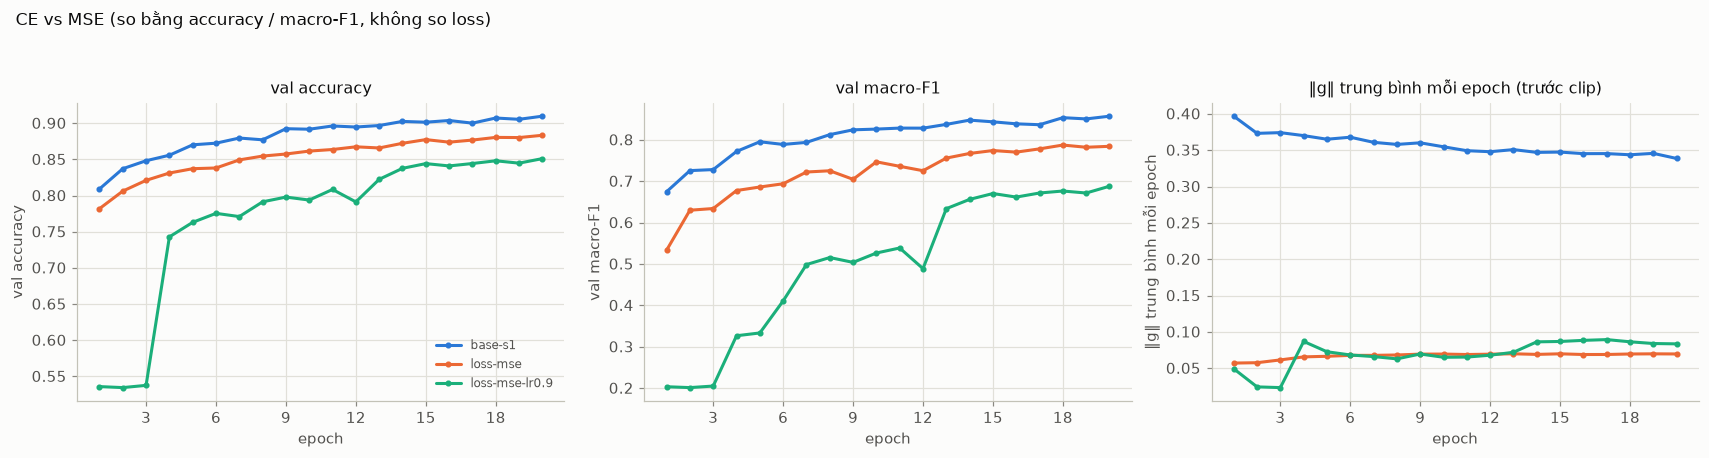

In [10]:
run("loss-mse", "loss", "MSE trên one-hot (logit), cùng lr baseline", loss="mse")
run(f"loss-mse-lr{3 * BASE_LR:g}", "loss", f"MSE trên one-hot, lr ×3 = {3 * BASE_LR:g}", loss="mse", lr=3 * BASE_LR,
    notes="đổi 2 yếu tố: loss + lr (bù gradient MSE nhỏ hơn ~3 lần)")
loss_ids = ["base-s1", "loss-mse", f"loss-mse-lr{3 * BASE_LR:g}"]
display(table(loss_ids))
plot_compare([RESULTS[e] for e in loss_ids], ["val_acc", "val_macro_f1", "grad_norm"], f"{FIG_DIR}/compare_loss.png",
             title="CE vs MSE (so bằng accuracy / macro-F1, không so loss)")
show(f"{FIG_DIR}/compare_loss.png")

**Đối chiếu sau khi chạy:** khớp hướng, sai ở chỗ tăng lr. `loss-mse` (cùng lr 0,3) có val F1 **0,7843**, kém baseline 0,075 (vượt 2σ = 0,020); accuracy 0,883 so với 0,910. Ngay epoch 1 F1 của MSE chỉ 0,533 so với 0,675 của CE, và ‖g‖ trung bình nhỏ hơn ~5 lần (0,067 so với 0,357), đúng với phân tích gradient `2(z−y)/(7B)` so với `(p−y)/B`. Train và val (đo bằng MSE) gần như trùng nhau (khoảng cách 0,001): MSE không quá khớp mà học chậm, và mục tiêu hồi quy về 0/1 không tối ưu ranh giới phân loại cho lớp hiếm.
**Khác dự đoán:** tăng lr ×3 (`loss-mse-lr0.9`) **không** thu hẹp khoảng cách mà còn tệ hơn (F1 0,688). Ở epoch 1 có một gai ‖g‖ = 10,8; sau đó F1 kẹt ở ~0,20 trong vài epoch rồi mới bò lên. Cách giải thích hợp lý nhất (chưa kiểm chứng trực tiếp): bước đầu quá lớn làm nhiều ReLU chết, giống `clip-none-lr3` ở 3.5. Vậy bù độ lớn gradient bằng lr không tương đương với dùng CE: gradient của MSE nhỏ ở mọi chỗ, nên lr lớn làm bước đầu vượt quá. Không so giá trị loss 0,027 (MSE) với 0,226 (CE) vì khác thang đo.

### 3.2 Bộ tối ưu hoá (`opt-*`)
Mỗi bộ tối ưu được thử 3–4 giá trị lr cách nhau ~3 lần, rồi so **ở lr tốt nhất của từng bộ** (theo val macro-F1). Tham số: SGD+momentum `momentum=0.9`; Adam/AdamW `betas=(0.9, 0.999)`, `eps=1e-8`; AdamW `weight_decay=0.01`; SGD và Adam `weight_decay=0`.

**Dự đoán trước:** SGD thuần cần lr lớn hơn SGD+momentum khoảng 10 lần mới có cùng bước hiệu dụng (η/(1−μ)), nên lưới của nó đặt ở 0,1–1. Adam chuẩn hoá bước theo √v̂ của từng tham số nên ít nhạy với tỉ lệ gradient; mình đoán Adam/AdamW ở lr ~1e-3–3e-3 xuống loss nhanh nhất trong vài epoch đầu và có val macro-F1 cao nhất sau 20 epoch, vượt SGD+momentum quá 2σ. Adam và AdamW (wd = 0,01) khác nhau không vượt nhiễu, vì mô hình đang chưa khớp hết nên suy giảm trọng số nhẹ không đổi nhiều. Với `weight_decay = 0`, AdamW phải cho đúng kết quả của Adam (kiểm chứng bằng một lần chạy).

*(Bổ sung sau lần chạy đầu, chưa chạm eval: lr tốt nhất của Adam/AdamW rơi vào mép 3e-3 nên thêm lr = 1e-2.)*

opt-sgd-lr0.1              best ep  18/20  val_loss 0.3428  acc 0.8582  F1 0.7425  |g| 0.921  0.30s/ep


opt-sgd-lr0.3              best ep  16/20  val_loss 0.2881  acc 0.8819  F1 0.8035  |g| 0.667  0.30s/ep


opt-sgd-lr1                best ep  15/20  val_loss 0.2548  acc 0.8985  F1 0.8232  |g| 0.450  0.30s/ep


opt-adam-lr0.0003          best ep  20/20  val_loss 0.3086  acc 0.8765  F1 0.7960  |g| 0.791  0.49s/ep


opt-adam-lr0.001           best ep  18/20  val_loss 0.2437  acc 0.9022  F1 0.8432  |g| 0.912  0.50s/ep


...

opt-adamw-lr0.003          best ep  18/20  val_loss 0.2116  acc 0.9170  F1 0.8646  |g| 0.654  0.51s/ep


opt-adamw-lr0.01           best ep  20/20  val_loss 0.2297  acc 0.9081  F1 0.8515  |g| 0.413  0.49s/ep

lr tốt nhất của từng bộ tối ưu (theo val macro-F1): {'SGD+momentum': 'opt-sgdm-lr0.3', 'SGD': 'opt-sgd-lr1', 'Adam': 'opt-adam-lr0.003', 'AdamW wd=0.01': 'opt-adamw-lr0.003'}


opt-adamw-wd0-lr0.003      best ep  18/20  val_loss 0.2127  acc 0.9160  F1 0.8719  |g| 0.673  0.48s/ep
max |Δ val_loss| giữa opt-adamw-wd0-lr0.003 và opt-adam-lr0.003 qua 20 epoch = 0.00e+00


,best_ep,step0,best_val_loss,gap_val_train,val_acc,val_F1,s_per_ep,diverged,ΔF1_vs_base,vượt 2σ?
exp_id,,,,,,,,,,
opt-sgdm-lr0.3,20,2.2691,0.2261,0.0250,0.9098,0.8571,0.3103,False,-0.0020,Không
opt-sgd-lr1,15,2.2691,0.2548,0.0220,0.8985,0.8232,0.2956,False,-0.0359,Có
opt-adam-lr0.003,18,2.2691,0.2127,0.0262,0.9160,0.8719,0.4842,False,0.0128,Không
opt-adamw-lr0.003,18,2.2691,0.2116,0.0252,0.9170,0.8646,0.5072,False,0.0055,Không


,best_ep,step0,best_val_loss,gap_val_train,val_acc,val_F1,s_per_ep,diverged,ΔF1_vs_base,vượt 2σ?
exp_id,,,,,,,,,,
opt-sgdm-lr0.01,19,2.2691,0.3162,0.0106,0.8721,0.7644,0.3215,False,-0.0947,Có
opt-sgdm-lr0.03,20,2.2691,0.2573,0.0166,0.8961,0.8280,0.3154,False,-0.0311,Có
opt-sgdm-lr0.1,20,2.2691,0.2332,0.0234,0.9087,0.8504,0.3102,False,-0.0086,Không
opt-sgdm-lr0.3,20,2.2691,0.2261,0.0250,0.9098,0.8571,0.3103,False,-0.0020,Không
opt-sgdm-lr1,20,2.2691,0.3541,0.0134,0.8612,0.7731,0.3158,False,-0.0860,Có
opt-sgd-lr0.1,18,2.2691,0.3428,0.0096,0.8582,0.7425,0.2966,False,-0.1165,Có
opt-sgd-lr0.3,16,2.2691,0.2881,0.0152,0.8819,0.8035,0.2951,False,-0.0556,Có
opt-sgd-lr1,15,2.2691,0.2548,0.0220,0.8985,0.8232,0.2956,False,-0.0359,Có
opt-adam-lr0.0003,20,2.2691,0.3086,0.0116,0.8765,0.7960,0.4853,False,-0.0631,Có


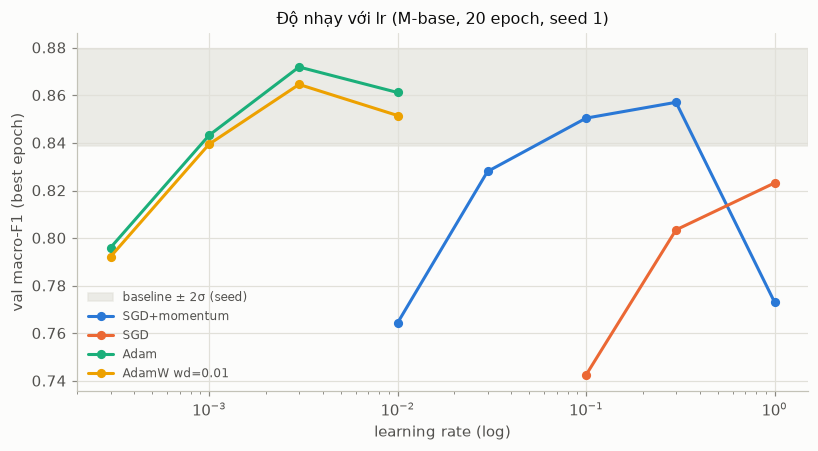

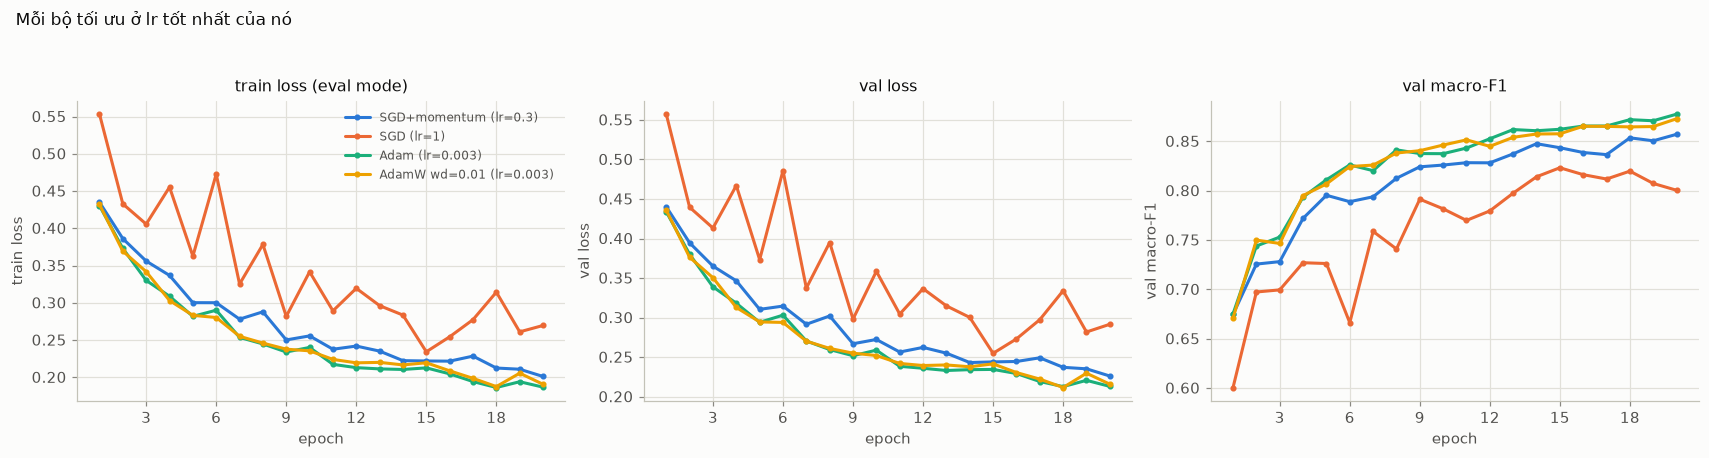

In [11]:
SWEEPS = {
    "SGD":          ("sgd",   [0.1, 0.3, 1.0],    dict()),
    "Adam":         ("adam",  [3e-4, 1e-3, 3e-3, 1e-2], dict()),      # 1e-2 bổ sung: 3e-3 ở mép lưới
    "AdamW wd=0.01": ("adamw", [3e-4, 1e-3, 3e-3, 1e-2], dict(weight_decay=0.01)),
}
TAG = {"sgd": "sgd", "adam": "adam", "adamw": "adamw"}
opt_runs = {"SGD+momentum": [f"opt-sgdm-lr{lr:g}" for lr in SWEEP_SGDM]}
for label, (opt, lrs, extra) in SWEEPS.items():
    opt_runs[label] = []
    for lr in lrs:
        e = f"opt-{TAG[opt]}-lr{lr:g}"
        run(e, "optimizer", f"{label}, lr={lr:g}", optimizer=opt, lr=lr, **extra)
        opt_runs[label].append(e)

best_of = {label: max(ids, key=f1) for label, ids in opt_runs.items()}
print("\nlr tốt nhất của từng bộ tối ưu (theo val macro-F1):", best_of)

# Kiểm chứng: AdamW với weight_decay = 0 phải trùng Adam (ở lr tốt nhất của Adam)
adam_best_lr = RESULTS[best_of["Adam"]]["cfg"]["lr"]
e_chk = f"opt-adamw-wd0-lr{adam_best_lr:g}"
run(e_chk, "optimizer", f"AdamW weight_decay=0, lr={adam_best_lr:g} (kiểm chứng = Adam)", optimizer="adamw",
    lr=adam_best_lr, weight_decay=0.0, notes=f"so với {best_of['Adam']}: phải trùng")
diff = np.max(np.abs(np.array(RESULTS[e_chk]["history"]["val_loss"]) - np.array(RESULTS[best_of["Adam"]]["history"]["val_loss"])))
print(f"max |Δ val_loss| giữa {e_chk} và {best_of['Adam']} qua 20 epoch = {diff:.2e}")

display(table(list(best_of.values())))
display(table([e for ids in opt_runs.values() for e in ids] + [e_chk]))
plot_lr_sensitivity({lab: [(RESULTS[e]["cfg"]["lr"], f1(e)) for e in ids] for lab, ids in opt_runs.items()},
                    f"{FIG_DIR}/compare_optimizer_lr.png", title="Độ nhạy với lr (M-base, 20 epoch, seed 1)",
                    ref=(BASE_F1_MEAN, NOISE_F1))
plot_compare([RESULTS[e] for e in best_of.values()], ["train_loss", "val_loss", "val_macro_f1"],
             f"{FIG_DIR}/compare_optimizer.png", title="Mỗi bộ tối ưu ở lr tốt nhất của nó",
             labels=[f"{lab} (lr={RESULTS[e]['cfg']['lr']:g})" for lab, e in best_of.items()])
show(f"{FIG_DIR}/compare_optimizer_lr.png")
show(f"{FIG_DIR}/compare_optimizer.png")

**Đối chiếu sau khi chạy:** ở lr tốt nhất của từng bộ: **Adam lr 3e-3: F1 0,8719**, AdamW (wd 0,01) lr 3e-3: 0,8646, SGD+momentum lr 0,3: 0,8571, SGD lr 1: 0,8232.
- **Adam so với SGD+momentum:** +0,013 so với trung bình baseline, **nhỏ hơn 2σ = 0,020, nên chưa kết luận được** Adam thắng. Dự đoán "Adam vượt quá 2σ" **sai**. Phần đúng: Adam xuống nhanh hơn ở các epoch đầu (val loss epoch 3: 0,339 so với 0,365; F1 epoch 3: 0,753 so với 0,728) nhờ chia bước theo √v̂ của từng tham số. Sau 20 epoch, SGD+momentum với lr đã chỉnh gần như bắt kịp.
- **SGD thuần thua rõ** (−0,036, vượt 2σ) dù đã dùng lr = 1 (ở mép lưới, có thể còn tăng được; nhưng ở lr 1 đã xuất hiện gai ‖g‖ = 9,2 ở epoch 1). Momentum cộng dồn hướng gradient nhất quán và triệt tiêu nhiễu, tương đương lr hiệu dụng gấp ~10 lần mà vẫn ổn định.
- **Adam so với AdamW (wd 0,01):** chênh 0,007, trong nhiễu, khớp dự đoán. **AdamW với wd = 0 trùng Adam đến từng bit** (max |Δ val_loss| = 0), xác nhận hai thuật toán chỉ khác ở cách xử lý weight decay.
- **Độ nhạy lr** (`compare_optimizer_lr.png`): đường của Adam/AdamW phẳng hơn quanh đỉnh (0,843 → 0,872 → 0,861 cho 1e-3 → 1e-2), còn SGD+momentum tụt từ 0,857 xuống 0,773 khi lr tăng từ 0,3 lên 1. Nếu không chỉnh lr (ví dụ cùng dùng lr = 0,01 cho mọi bộ), kết luận sẽ là "Adam (0,861) hơn SGD+momentum (0,764) gần 0,1 điểm", một khác biệt chủ yếu do lr chứ không do thuật toán.

### 3.3 Hyper-parameter (`hp-*`): batch, độ rộng, độ sâu, số epoch, lịch lr, weight decay
Mọi thí nghiệm giữ SGD+momentum với lr baseline, chỉ đổi một yếu tố (riêng `hp-bs2048-lrx4-warmup` đổi theo "quy tắc tăng lr theo lô": batch ×4, lr ×4, khởi động tuyến tính 1 epoch).

**Dự đoán trước:**
- *Batch.* Cùng 20 epoch: batch 128 có 2 906 bước/epoch, gấp 4 lần batch 512 (727 bước), batch 2048 chỉ có 182 bước. Vì baseline chưa hội tụ, số bước là yếu tố quyết định: `hp-bs128` tốt hơn (vượt 2σ) nhưng chậm hơn ~3 lần mỗi epoch; `hp-bs2048` kém hơn rõ. Tăng lr ×4 kèm khởi động lấy lại phần lớn khoảng cách vì mỗi bước đi xa hơn tương ứng, nhưng có thể chưa bằng baseline.
- *Kiến trúc.* Baseline đang chưa khớp (train ≈ val), nên thêm năng lực có ích: `hp-wide` (161k tham số) tốt hơn vượt 2σ; `hp-deep` (thêm lớp 64) chỉ thêm 8k tham số, mình đoán chênh lệch nằm trong nhiễu.
- *Epoch.* `hp-ep40` (gấp đôi số bước) tốt hơn vượt 2σ, best epoch vẫn là epoch cuối hoặc gần cuối.
- *Lịch lr.* `hp-cosine` (giảm lr theo cosine về 0 trong 20 epoch) cho val loss cuối thấp hơn vì lr nhỏ dần làm giảm nhiễu của SGD ở cuối; mình đoán F1 tăng nhẹ, có thể vượt 2σ.
- *Weight decay.* `hp-wd5e-4` (L2 qua SGD): mô hình chưa quá khớp nên chính quy hoá không giúp, F1 bằng hoặc kém nhẹ.

hp-bs128                   best ep  17/20  val_loss 0.3327  acc 0.8621  F1 0.7958  |g| 0.444  1.20s/ep


hp-bs2048                  best ep  20/20  val_loss 0.2438  acc 0.9035  F1 0.8399  |g| 0.430  0.09s/ep


hp-bs2048-lrx4-warmup      best ep  20/20  val_loss 0.2210  acc 0.9114  F1 0.8611  |g| 0.228  0.10s/ep


hp-wide                    best ep  20/20  val_loss 0.1972  acc 0.9221  F1 0.8736  |g| 0.345  0.36s/ep


hp-deep                    best ep  20/20  val_loss 0.2198  acc 0.9127  F1 0.8537  |g| 0.374  0.37s/ep


hp-ep40                    best ep  36/40  val_loss 0.2019  acc 0.9237  F1 0.8757  |g| 0.345  0.31s/ep


hp-cosine                  best ep  20/20  val_loss 0.1681  acc 0.9340  F1 0.8885  |g| 0.372  0.31s/ep


hp-wd5e-4                  best ep  15/20  val_loss 0.3894  acc 0.8382  F1 0.7076  |g| 0.405  0.32s/ep


,steps/epoch,best_ep,step0,best_val_loss,gap_val_train,val_acc,val_F1,s_per_ep,diverged,ΔF1_vs_base,vượt 2σ?
exp_id,,,,,,,,,,,
base-s1,727,20,2.2691,0.2261,0.0250,0.9098,0.8571,0.3090,False,-0.0020,Không
hp-bs128,2906,17,2.2691,0.3327,0.0227,0.8621,0.7958,1.2003,False,-0.0633,Có
hp-bs2048,182,20,2.2691,0.2438,0.0192,0.9035,0.8399,0.0927,False,-0.0192,Không
hp-bs2048-lrx4-warmup,182,20,2.2691,0.2210,0.0239,0.9114,0.8611,0.0959,False,0.0020,Không
hp-wide,727,20,1.9182,0.1972,0.0321,0.9221,0.8736,0.3601,False,0.0146,Không
hp-deep,727,20,1.9099,0.2198,0.0231,0.9127,0.8537,0.3721,False,-0.0054,Không
hp-ep40,727,36,2.2691,0.2019,0.0330,0.9237,0.8757,0.3090,False,0.0166,Không
hp-cosine,727,20,2.2691,0.1681,0.0310,0.9340,0.8885,0.3126,False,0.0295,Có
hp-wd5e-4,727,15,2.2691,0.3894,0.0073,0.8382,0.7076,0.3181,False,-0.1515,Có


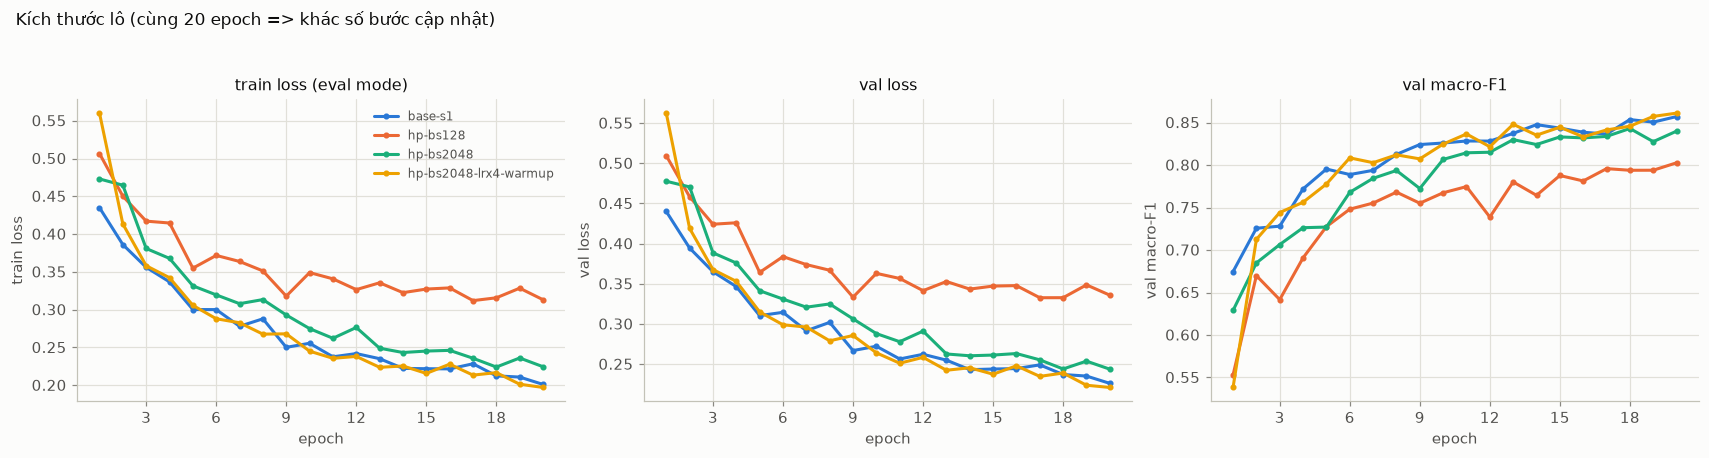

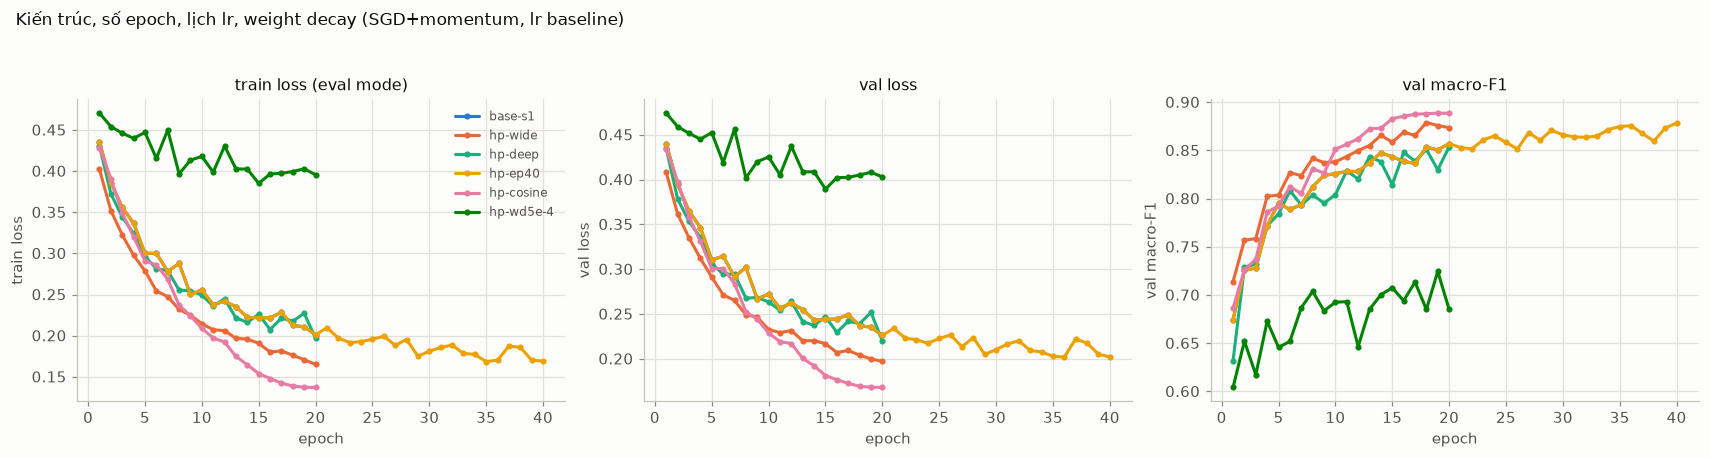

In [12]:
spe = lambda b: math.ceil(len(data["X_tr"]) / b)
run("hp-bs128", "hparam", "batch 128 (×4 số bước/epoch)", batch=128)
run("hp-bs2048", "hparam", "batch 2048 (÷4 số bước/epoch), cùng lr", batch=2048)
run("hp-bs2048-lrx4-warmup", "hparam", f"batch 2048, lr ×4 = {4 * BASE_LR:g}, khởi động 1 epoch", batch=2048,
    lr=4 * BASE_LR, scheduler="warmup", warmup_steps=spe(2048), notes="quy tắc tăng lr theo lô: đổi batch + lr + warmup")
run("hp-wide", "hparam", "M-wide 54-512-256-7 (161 287 tham số)", hidden=(512, 256))
run("hp-deep", "hparam", "M-deep 54-256-128-64-7 (55 687 tham số)", hidden=(256, 128, 64))
run("hp-ep40", "hparam", "40 epoch thay vì 20", epochs=40)
run("hp-cosine", "hparam", "lịch lr cosine về 0 trong 20 epoch", scheduler="cosine")
run("hp-wd5e-4", "hparam", "weight_decay 5e-4 (L2 qua SGD)", weight_decay=5e-4)
hp_ids = ["hp-bs128", "hp-bs2048", "hp-bs2048-lrx4-warmup", "hp-wide", "hp-deep", "hp-ep40", "hp-cosine", "hp-wd5e-4"]
T = table(["base-s1"] + hp_ids)
T.insert(0, "steps/epoch", [RESULTS[e]["summary"]["steps_per_epoch"] for e in T.index])
display(T)
plot_compare([RESULTS[e] for e in ["base-s1", "hp-bs128", "hp-bs2048", "hp-bs2048-lrx4-warmup"]],
             ["train_loss", "val_loss", "val_macro_f1"], f"{FIG_DIR}/compare_hparam_batch.png",
             title="Kích thước lô (cùng 20 epoch => khác số bước cập nhật)")
plot_compare([RESULTS[e] for e in ["base-s1", "hp-wide", "hp-deep", "hp-ep40", "hp-cosine", "hp-wd5e-4"]],
             ["train_loss", "val_loss", "val_macro_f1"], f"{FIG_DIR}/compare_hparam.png",
             title="Kiến trúc, số epoch, lịch lr, weight decay (SGD+momentum, lr baseline)")
show(f"{FIG_DIR}/compare_hparam_batch.png")
show(f"{FIG_DIR}/compare_hparam.png")

**Đối chiếu sau khi chạy:** (số bước/epoch: 2 906 / 727 / 182 cho batch 128 / 512 / 2048)
- **Batch 128: sai dự đoán.** F1 0,7958 (−0,063, vượt 2σ) dù có gấp 4 lần số bước. Lý do: giữ nguyên lr = 0,3 khi giảm batch 4 lần làm phương sai của bước cập nhật (∝ lr²/B) tăng ~4 lần. ‖g‖ lớn nhất mỗi epoch lên tới 3–4, val loss dao động; mô hình bị nhiễu quá mức chứ không thiếu bước. Đây là mặt ngược của quy tắc tăng lr theo lô: giảm batch thì cũng phải giảm lr. Ngoài ra mỗi epoch chậm gần 4 lần (1,20 s so với 0,31 s) vì chi phí cố định mỗi bước.
- **Batch 2048 cùng lr:** F1 0,8399 (−0,019, sát ngưỡng 2σ nhưng chưa vượt), khớp hướng dự đoán: ít bước hơn 4 lần nên chưa học đủ. **Batch 2048 + lr ×4 + khởi động:** F1 0,8611, ngang baseline (+0,002), dù chỉ có 182 bước/epoch và nhanh hơn 3 lần mỗi epoch (0,10 s). Quy tắc tăng lr theo lô hoạt động: bước dài gấp 4 lần bù cho số bước ít hơn 4 lần; khởi động 1 epoch tránh để lr 1,2 làm hỏng mạng ngay từ đầu (ở epoch 1 F1 còn thấp, 0,538).
- **M-wide:** F1 0,8736 (+0,015, trong nhiễu); val loss tốt hơn rõ (0,197 so với 0,226) nhưng khoảng cách val − train tăng (0,032). **M-deep:** 0,8537, trong nhiễu, khớp dự đoán.
- **40 epoch:** F1 0,8757 (+0,017, **chưa vượt 2σ**; dự đoán "vượt" sai). Best epoch 36: thêm bước giúp nhưng với lr hằng 0,3 val loss răng cưa nên lợi ích bị nhiễu che.
- **Lịch lr cosine:** F1 **0,8885 (+0,030, vượt 2σ)**, val loss thấp nhất trong nhóm (0,168), cùng số bước với baseline. Khớp dự đoán và còn mạnh hơn dự kiến: lr giảm dần về 0 làm giảm nhiễu của SGD ở cuối, mô hình "hạ cánh" vào đáy của vùng hiện tại thay vì nảy quanh nó. Đây là thay đổi có lợi nhất trong toàn bộ thí nghiệm.
- **Weight decay 5e-4:** F1 0,7076 (−0,15), kém hơn nhiều so với dự đoán "kém nhẹ". Với lr 0,3, mỗi bước co trọng số theo hệ số (1 − lr·λ) = 1 − 1,5·10⁻⁴; qua 14 540 bước tích luỹ thành co ~e^(−2,2) nếu gradient không bù lại. Mô hình vốn chưa khớp hết nên bị kéo về phía chưa khớp nặng hơn (train loss 0,396, khoảng cách chỉ 0,007).

### 3.4 Dropout (`drop-*`)
Dropout đặt sau ReLU của hai lớp ẩn; train loss vẫn đo ở eval mode nên so được với val loss.

**Dự đoán trước:** khoảng cách val − train loss của baseline gần 0 (xem bảng 2b), tức mô hình **chưa quá khớp**. Dropout là thuốc chữa quá khớp: nó giảm năng lực hiệu dụng và thêm nhiễu vào gradient. Vì vậy mình đoán val macro-F1 giảm dần khi q tăng (q = 0,1 có thể nằm trong nhiễu, q = 0,3 và 0,5 kém hơn vượt 2σ), lớp hiếm chịu thiệt nhiều nhất; khoảng cách val − train vẫn ≈ 0. Loss lúc huấn luyện (có dropout) sẽ cao hơn loss đo ở eval mode.

drop-0.1                   best ep  20/20  val_loss 0.2390  acc 0.9033  F1 0.8391  |g| 0.291  0.32s/ep


drop-0.3                   best ep  20/20  val_loss 0.3121  acc 0.8718  F1 0.7899  |g| 0.284  0.32s/ep


drop-0.5                   best ep  20/20  val_loss 0.4185  acc 0.8237  F1 0.6475  |g| 0.294  0.32s/ep


,best_ep,step0,best_val_loss,train_loss_running_cuối,gap_val_train,val_acc,val_F1,s_per_ep,diverged,ΔF1_vs_base,vượt 2σ?
exp_id,,,,,,,,,,,
base-s1,20,2.2691,0.2261,0.2133,0.0250,0.9098,0.8571,0.3090,False,-0.0020,Không
drop-0.1,20,2.2691,0.2390,0.2876,0.0121,0.9033,0.8391,0.3242,False,-0.0200,Không
drop-0.3,20,2.2691,0.3121,0.3957,0.0073,0.8718,0.7899,0.3243,False,-0.0692,Có
drop-0.5,20,2.2691,0.4185,0.5073,0.0042,0.8237,0.6475,0.3249,False,-0.2115,Có


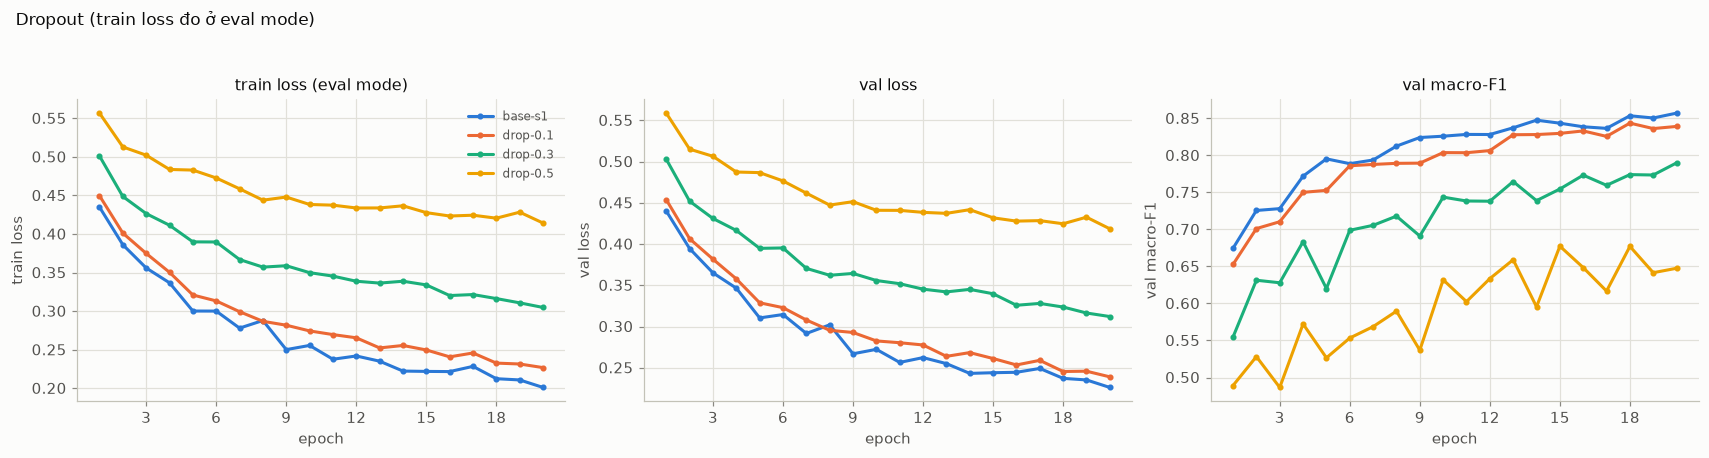

In [13]:
for q in (0.1, 0.3, 0.5):
    run(f"drop-{q:g}", "dropout", f"dropout q={q:g} sau ReLU của mỗi lớp ẩn", dropout=q)
drop_ids = ["base-s1", "drop-0.1", "drop-0.3", "drop-0.5"]
T = table(drop_ids)
T.insert(3, "train_loss_running_cuối", [RESULTS[e]["history"]["train_loss_running"][-1] for e in drop_ids])
display(T.round(4))
plot_compare([RESULTS[e] for e in drop_ids], ["train_loss", "val_loss", "val_macro_f1"], f"{FIG_DIR}/compare_dropout.png",
             title="Dropout (train loss đo ở eval mode)")
show(f"{FIG_DIR}/compare_dropout.png")

**Đối chiếu sau khi chạy:** khớp dự đoán. F1 giảm đơn điệu theo q: 0,8571 → **0,8391 (q 0,1, −0,020, sát ngưỡng nhưng chưa vượt 2σ)** → 0,7899 (q 0,3) → 0,6475 (q 0,5), hai mức sau vượt 2σ. Khoảng cách val − train (cả hai đo ở eval mode) thu hẹp 0,025 → 0,012 → 0,007 → 0,004, nhưng là vì **train loss tăng** (0,201 → 0,414 ở q 0,5), không phải vì val loss giảm. Loss lúc huấn luyện (có dropout) cao hơn loss đo ở eval mode (ví dụ q 0,5: 0,507 so với 0,414), đúng như GUIDE cảnh báo. Dropout không giúp khi mô hình chưa quá khớp: nó thêm nhiễu và giảm năng lực hiệu dụng của một mạng vốn đã thiếu năng lực. Nên dùng khi train loss thấp hơn val loss rõ rệt và khoảng cách lớn dần theo epoch (val loss quay đầu đi lên).

### 3.5 Gradient clipping (`clip-*`)
Công thức: `g ← g · min(1, c/‖g‖)` với ‖g‖ là chuẩn L2 toàn cục (`clip_grad_norm_`). `grad_norm` luôn được ghi **trước** khi cắt.

Chọn `c` từ phân phối ‖g‖ từng bước của `base-s1`: lấy **trung vị** (làm tròn 2 chữ số) để clipping thực sự kích hoạt ở khoảng một nửa số bước.

**Dự đoán trước:**
- Ở lr baseline: huấn luyện vốn ổn định (không có gai lớn), nên cắt gradient chỉ thu nhỏ một số bước. Mình đoán val macro-F1 thay đổi trong phạm vi nhiễu (có thể thấp hơn nhẹ vì bước bị thu nhỏ).
- Phản chứng ở lr cao (×3 và ×10): không clip thì bước đầu tiên (‖g‖ lớn nhất lúc khởi tạo) nhân với lr lớn và momentum sẽ đẩy trọng số đi quá xa: loss dao động mạnh hoặc thành NaN, hoặc ReLU chết hàng loạt và mạng sụp về đoán lớp đa số. Có clip thì độ dài mỗi bước bị chặn bởi lr·c, nên huấn luyện vẫn hữu hạn và đạt F1 hợp lý (dù có thể thấp hơn baseline).

*(Bổ sung sau lần chạy đầu, chưa chạm eval: thiết kế ban đầu chỉ có lr ×10, ở đó cả hai bản đều sụp về đoán lớp đa số; thêm lr ×3 để thấy vùng clipping có tác dụng.)*

‖g‖ từng bước của base-s1 (1/10 số bước): p5 0.289 | p25 0.323 | p50 0.350 | p75 0.381 | p95 0.440 | max 2.871
=> c = 0.35; ở base-s1, 50% số bước có ‖g‖ > c


clip-0.35                  best ep  18/20  val_loss 0.2285  acc 0.9084  F1 0.8617  |g| 0.380  0.33s/ep


clip-none-lr0.9            best ep  17/20  val_loss 0.3296  acc 0.8687  F1 0.7928  |g| 0.256  0.31s/ep


clip-0.35-lr0.9            best ep  19/20  val_loss 0.2785  acc 0.8938  F1 0.8263  |g| 0.256  0.32s/ep


clip-none-lr3              best ep  19/20  val_loss 1.2072  acc 0.4876  F1 0.0936  |g| 0.100  0.31s/ep


clip-0.35-lr3              best ep   3/20  val_loss 0.9551  acc 0.5249  F1 0.1931  |g| 0.157  0.32s/ep


,%bước bị cắt,‖g‖ max,best_ep,step0,best_val_loss,gap_val_train,val_acc,val_F1,s_per_ep,diverged,ΔF1_vs_base,vượt 2σ?
exp_id,,,,,,,,,,,,
base-s1,0.0000,2.8711,20,2.2691,0.2261,0.0250,0.9098,0.8571,0.3090,False,-0.0020,Không
clip-0.35,68.0468,2.8711,18,2.2691,0.2285,0.0281,0.9084,0.8617,0.3260,False,0.0026,Không
clip-none-lr0.9,0.0000,10.0414,17,2.2691,0.3296,0.0202,0.8687,0.7928,0.3118,False,-0.0663,Có
clip-0.35-lr0.9,1.9188,2.9890,19,2.2691,0.2785,0.0273,0.8938,0.8263,0.3243,False,-0.0327,Có
clip-none-lr3,0.0000,163.5315,19,2.2691,1.2072,0.0000,0.4876,0.0936,0.3115,False,-0.7654,Có
clip-0.35-lr3,3.7758,4.4027,3,2.2691,0.9551,-0.0010,0.5249,0.1931,0.3244,False,-0.6660,Có


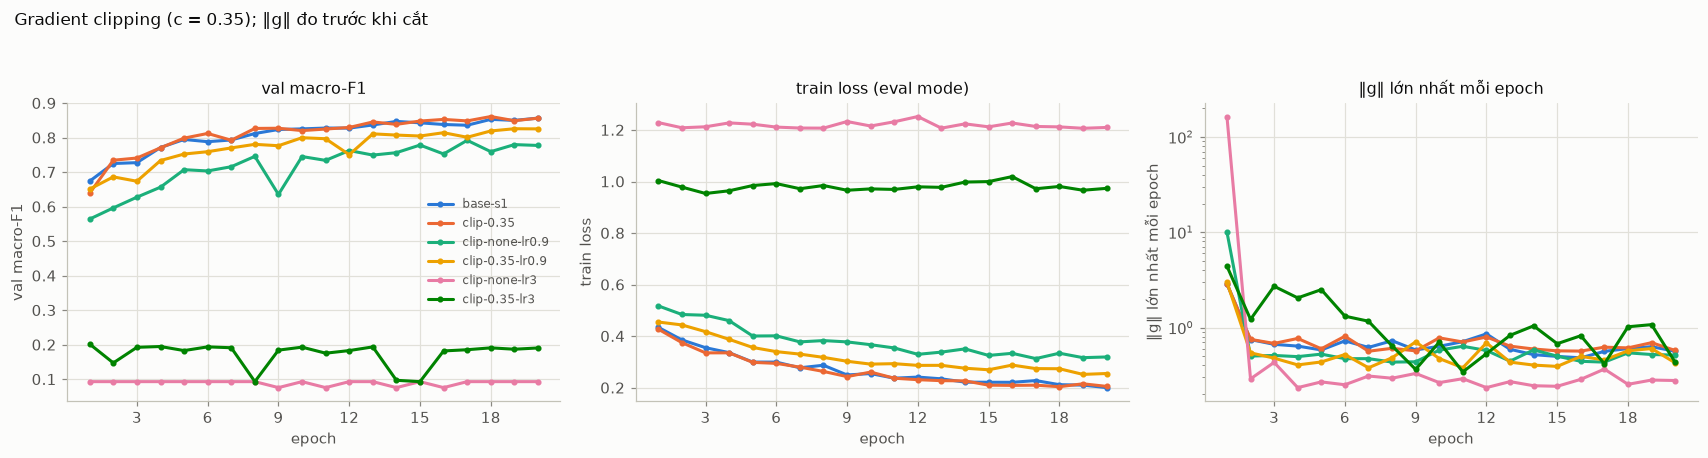

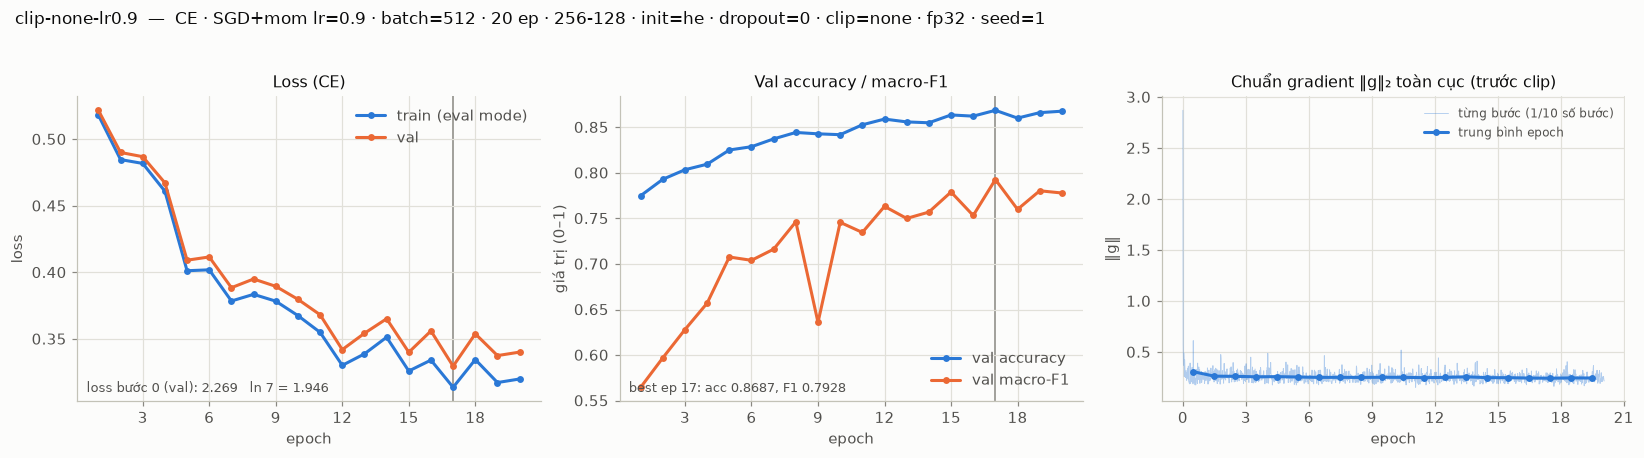

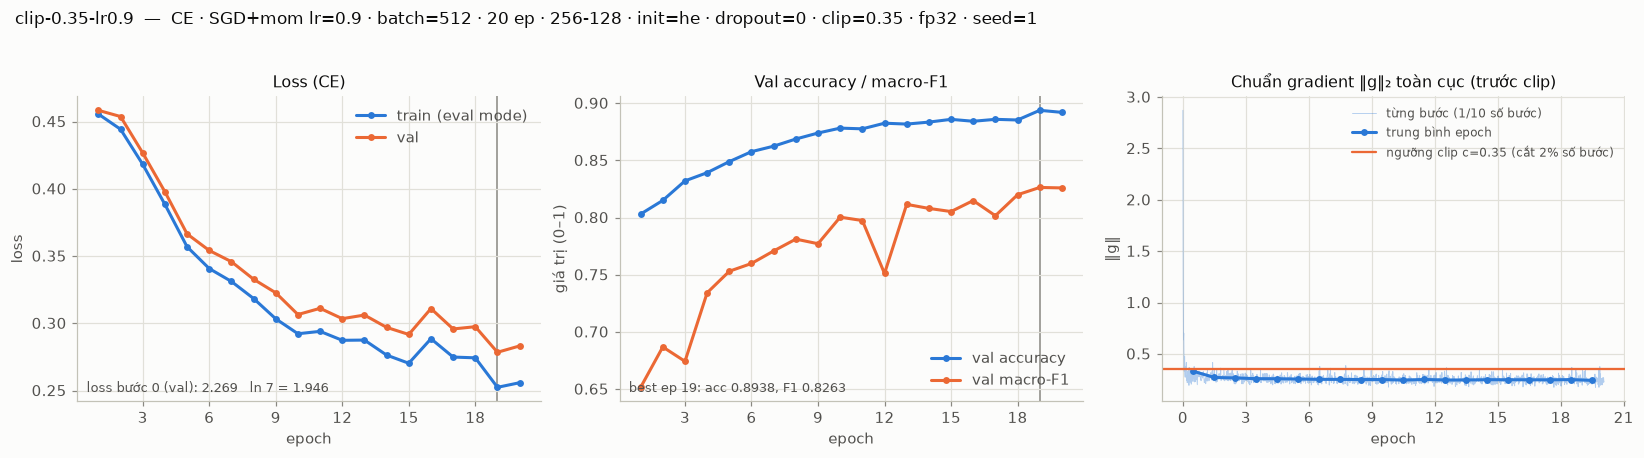

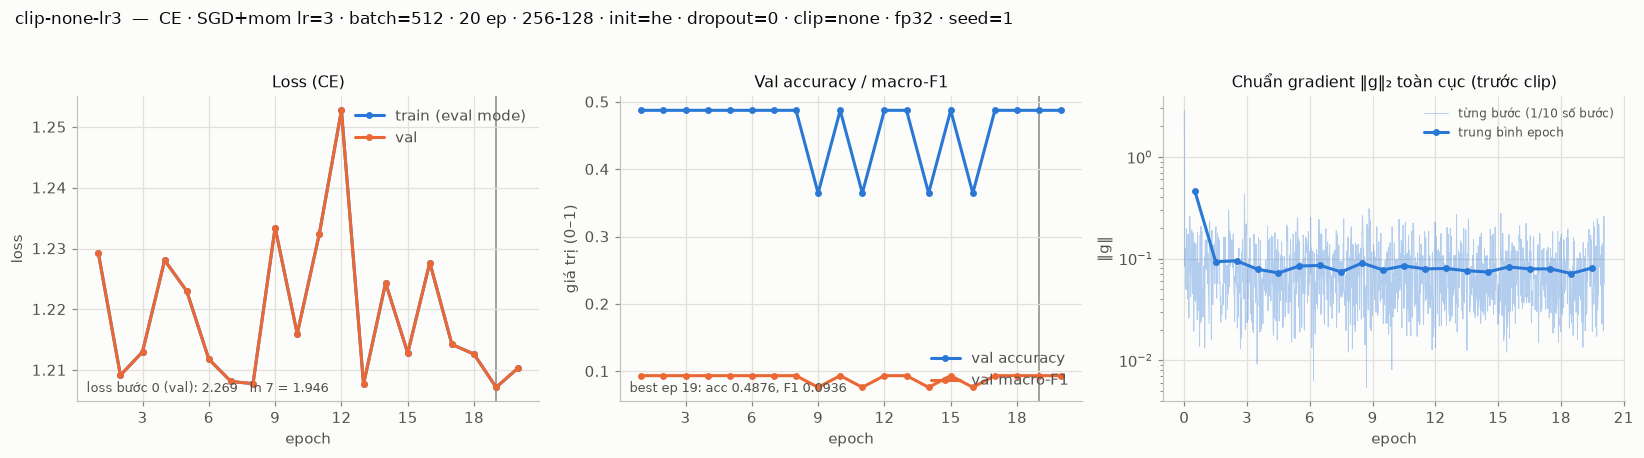

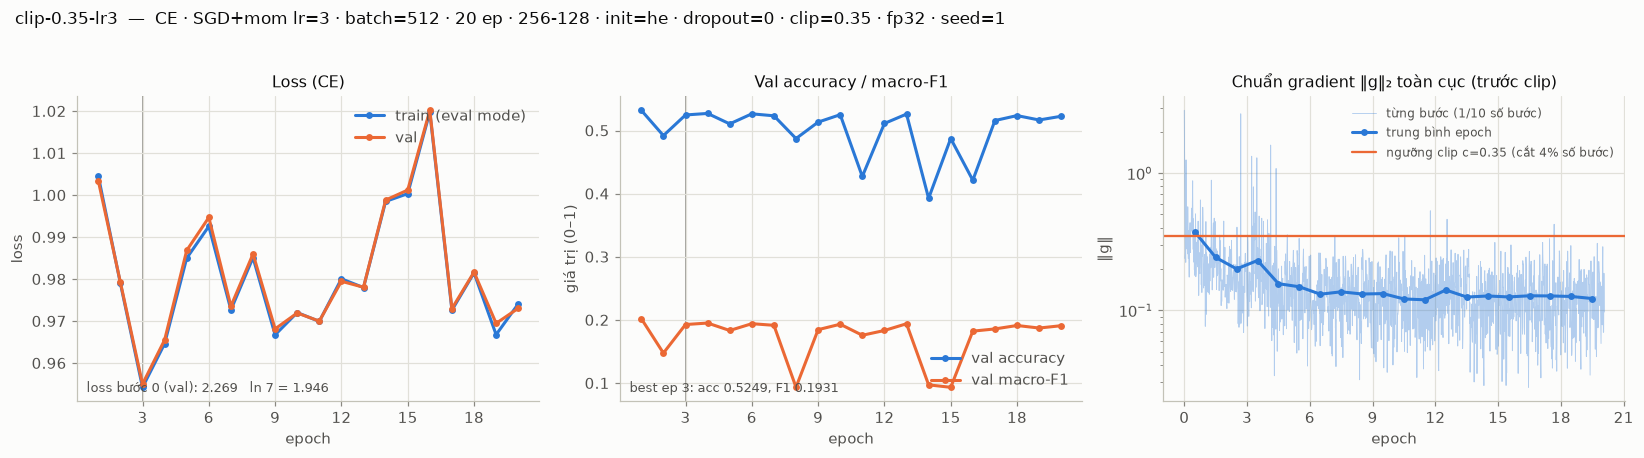

In [14]:
gn_steps = np.array(RESULTS["base-s1"]["history"]["grad_norm_steps"], dtype=float)
q = np.nanpercentile(gn_steps, [5, 25, 50, 75, 95, 100])
print("‖g‖ từng bước của base-s1 (1/10 số bước): p5 {:.3f} | p25 {:.3f} | p50 {:.3f} | p75 {:.3f} | p95 {:.3f} | max {:.3f}".format(*q))
C_CLIP = float(f"{q[2]:.2g}")
print(f"=> c = {C_CLIP:g}; ở base-s1, {100 * np.mean(gn_steps > C_CLIP):.0f}% số bước có ‖g‖ > c")

LR_HIGHS = [3 * BASE_LR, 10 * BASE_LR]
run(f"clip-{C_CLIP:g}", "clipping", f"clip c={C_CLIP:g} (trung vị ‖g‖ của baseline), lr baseline", clip_norm=C_CLIP)
clip_ids = ["base-s1", f"clip-{C_CLIP:g}"]
for k, lrh in zip((3, 10), LR_HIGHS):
    run(f"clip-none-lr{lrh:g}", "clipping", f"KHÔNG clip, lr ×{k} = {lrh:g}", lr=lrh,
        notes="phản chứng: đổi lr so với baseline; so với dòng có clip cùng lr")
    run(f"clip-{C_CLIP:g}-lr{lrh:g}", "clipping", f"clip c={C_CLIP:g}, lr ×{k} = {lrh:g}", lr=lrh, clip_norm=C_CLIP,
        notes="phản chứng: đổi lr + clip so với baseline; so với dòng không clip cùng lr")
    clip_ids += [f"clip-none-lr{lrh:g}", f"clip-{C_CLIP:g}-lr{lrh:g}"]
T = table(clip_ids)
T.insert(0, "%bước bị cắt", [100 * RESULTS[e]["summary"]["mean_frac_clipped"] for e in clip_ids])
T.insert(1, "‖g‖ max", [np.nanmax(RESULTS[e]["history"]["grad_norm_max"]) for e in clip_ids])
display(T.round(4))
plot_compare([RESULTS[e] for e in clip_ids], ["val_macro_f1", "train_loss", "grad_norm_max"], f"{FIG_DIR}/compare_clipping.png",
             title=f"Gradient clipping (c = {C_CLIP:g}); ‖g‖ đo trước khi cắt")
show(f"{FIG_DIR}/compare_clipping.png")
for lrh in LR_HIGHS:
    show(f"{FIG_DIR}/clip-none-lr{lrh:g}.png")
    show(f"{FIG_DIR}/clip-{C_CLIP:g}-lr{lrh:g}.png")

**Đối chiếu sau khi chạy:** `grad_norm` của baseline rất đều (p5–p95 = 0,29–0,44), chỉ có một gai 2,87 ở **bước đầu tiên** (gradient lúc khởi tạo). c = 0,35 = trung vị.
- **lr baseline:** `clip-0.35` cắt 68% số bước (nhiều hơn 50% vì khi bị cắt quỹ đạo khác đi và ‖g‖ có xu hướng lớn hơn), F1 0,8617 (+0,003, trong nhiễu), khớp dự đoán: không có bất ổn thì clipping chỉ là thu nhỏ bước, không giúp mà cũng không hại đáng kể.
- **lr ×3 = 0,9:** không clip có gai ‖g‖ = **10,0** ở epoch 1 và chỉ đạt F1 0,7928; có clip thì ‖g‖ lớn nhất chỉ còn 2,99 và F1 **0,8263 (+0,034 so với bản không clip, vượt 2σ)**. Clipping chỉ cắt 20% số bước ở epoch 1 và 1–2% về sau, nghĩa là nó chỉ can thiệp đúng lúc có gai. Đây là bằng chứng clipping giải quyết vấn đề *gradient đột ngột lớn*.
- **lr ×10 = 3:** **khác dự đoán**, cả hai bản đều hỏng. Không clip: gai ‖g‖ = 163 ở epoch 1, sau đó mạng đoán toàn lớp 1 (acc 0,4876, F1 0,094). Val loss kẹt ở 1,21 ≈ entropy của phân phối lớp (1,205), tức logit chỉ còn là bias: ReLU chết hàng loạt chứ không thành NaN (CE tính từ logit nên ổn định số, cờ `diverged` không bật). Có clip: F1 0,193, best epoch 3. Clipping chặn độ lớn *gradient* nhưng với momentum 0,9 bước *cập nhật* vẫn có thể dài tới lr·c/(1−μ) ≈ 3·0,35·10 ≈ 10, quá lớn so với độ lớn trọng số. Clipping không thay được việc chọn lr hợp lý.

### 3.6 Mixed precision (`amp-*`)
`torch.autocast(device_type, dtype=float16|bfloat16)` chỉ bọc forward + loss (logit ép về FP32 trước khi tính loss); tham số và trạng thái optimizer vẫn FP32. FP16 dùng `torch.amp.GradScaler` và luôn `unscale_` trước khi đo/cắt gradient; BF16 không dùng scaler.

Vì sao FP16 cần nhân loss với hệ số `s` còn BF16 thường không: FP16 có 5 bit mũ (số dương nhỏ nhất ~6·10⁻⁸, lớn nhất 65 504), gradient nhỏ dễ bị làm tròn về 0 (underflow); nhân loss với `s` đẩy gradient vào vùng biểu diễn được rồi chia lại trước khi cập nhật. BF16 có 8 bit mũ như FP32 (khoảng ~10⁻³⁸ đến ~3·10³⁸) nên gần như không underflow, chỉ kém chính xác hơn (7 bit phần định trị).

Ngoài `M-base`, mình đo thêm một mạng rất rộng `2048-2048` (4,3 triệu tham số, **chỉ 5 epoch**, chỉ để đo tốc độ; ba dòng `amp-xwide-*` so với nhau, không so với baseline).

**Dự đoán trước:**
- `M-base`: accuracy và macro-F1 của FP16/BF16 bằng FP32 trong phạm vi nhiễu (mạng nông, loss tính ở FP32). Không nhanh hơn: mỗi bước chỉ vài phép nhân ma trận nhỏ (512×54×256…), thời gian bị chi phối bởi chi phí gọi kernel, autocast còn thêm kernel ép kiểu. Bộ nhớ cực đại gần như không đổi vì bị chi phối bởi dữ liệu nằm trên GPU, activation chỉ vài MB.
- `M-xwide`: phép nhân 2048×2048 chiếm ưu thế nên nửa độ chính xác có cơ hội nhanh hơn; nhưng trên GPU Apple (MPS) mình không chắc FP16/BF16 có đường tính nhanh hơn FP32 hay không, nên chỉ kết luận theo số đo.

bf16 trên CUDA: không có CUDA | device đang dùng: mps


amp-fp16                   best ep  15/20  val_loss 0.2309  acc 0.9077  F1 0.8467  |g| 0.354  0.61s/ep


amp-bf16                   best ep  19/20  val_loss 0.2195  acc 0.9122  F1 0.8566  |g| 0.354  0.34s/ep


amp-xwide-fp32             best ep   5/5   val_loss 0.2464  acc 0.8983  F1 0.8313  |g| 0.370  7.50s/ep


amp-xwide-fp16             best ep   5/5   val_loss 0.2533  acc 0.8951  F1 0.8266  |g| 0.371  6.08s/ep


amp-xwide-bf16             best ep   5/5   val_loss 0.2493  acc 0.8977  F1 0.8345  |g| 0.371  5.31s/ep


,best_ep,step0,best_val_loss,gap_val_train,val_acc,val_F1,s_per_ep,diverged,ΔF1_vs_base,vượt 2σ?
exp_id,,,,,,,,,,
base-s1,20,2.2691,0.2261,0.0250,0.9098,0.8571,0.3090,False,-0.0020,Không
amp-fp16,15,2.2691,0.2309,0.0260,0.9077,0.8467,0.6119,False,-0.0124,Không
amp-bf16,19,2.2691,0.2195,0.0251,0.9122,0.8566,0.3416,False,-0.0025,Không


,s_per_ep_mean,s_per_ep_median,epoch1_s,peak_mem_MB,peak_mem_train_MB,best_val_loss,val_acc,val_F1,skipped_steps
exp_id,,,,,,,,,
base-s1,0.3090,0.3077,0.3039,131.0771,4.3127,0.2261,0.9098,0.8571,0
amp-fp16,0.6119,0.6090,0.6629,131.1516,4.3872,0.2309,0.9077,0.8467,4
amp-bf16,0.3416,0.3408,0.3654,131.1511,4.3867,0.2195,0.9122,0.8566,0
amp-xwide-fp32,7.5021,7.5010,7.6426,187.5684,60.8040,0.2464,0.8983,0.8313,0
amp-xwide-fp16,6.0770,6.0772,6.5924,192.6655,65.9011,0.2533,0.8951,0.8266,1
amp-xwide-bf16,5.3074,5.3144,5.6305,192.6650,65.9006,0.2493,0.8977,0.8345,0


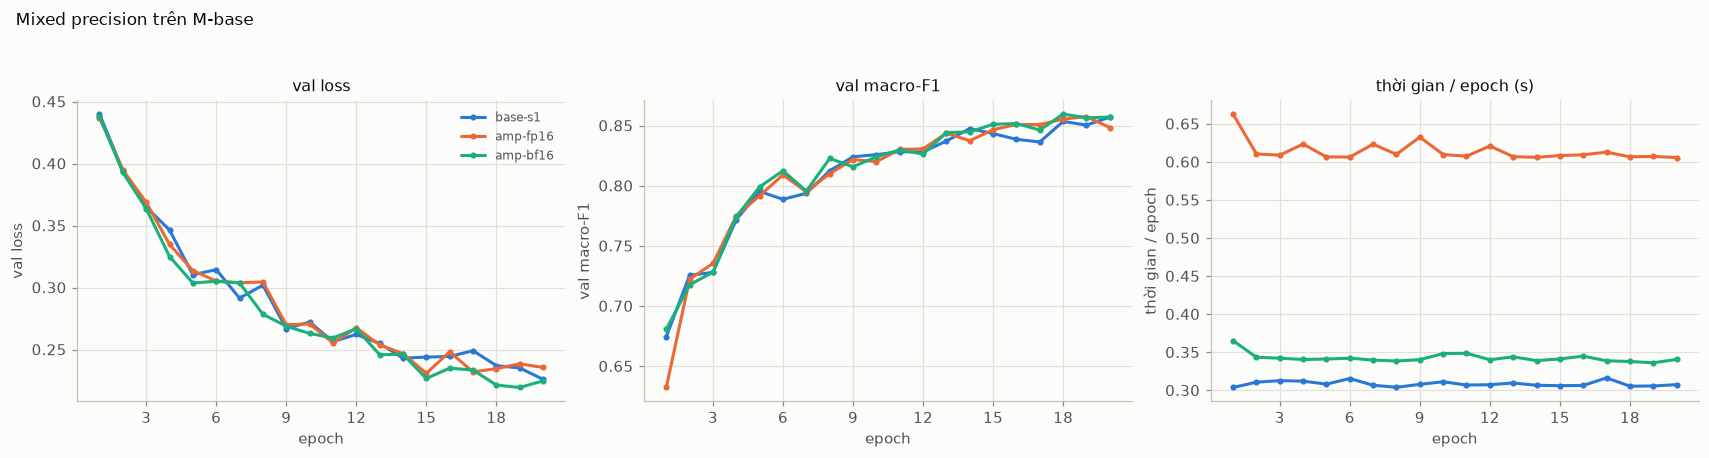

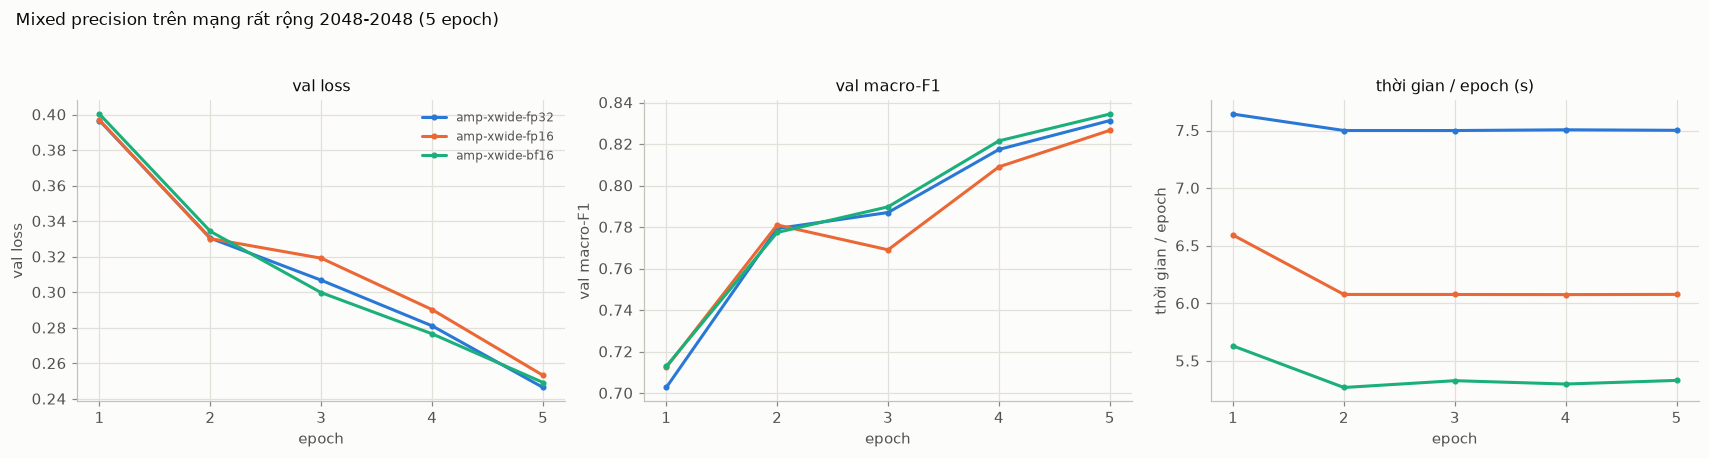

In [15]:
print("bf16 trên CUDA:", torch.cuda.is_bf16_supported() if torch.cuda.is_available() else "không có CUDA",
      "| device đang dùng:", device)
amp_ids = ["base-s1"]
for prec in ("fp16", "bf16"):
    try:
        run(f"amp-{prec}", "amp", f"autocast {prec.upper()}" + (" + GradScaler" if prec == "fp16" else ""), precision=prec)
        amp_ids.append(f"amp-{prec}")
    except Exception as ex:   # ví dụ GPU không hỗ trợ BF16: ghi lý do, không làm hỏng notebook
        print(f"amp-{prec} không chạy được trên {device}: {ex!r}")

xw_ids = []
for prec in ("fp32", "fp16", "bf16"):
    try:
        run(f"amp-xwide-{prec}", "amp", f"M-xwide 2048-2048, {prec.upper()}, 5 epoch (đo tốc độ)", hidden=(2048, 2048),
            precision=prec, epochs=5, notes="kiến trúc 2048-2048 ngoài bảng quy định + 5 epoch: chỉ để đo tốc độ AMP; chỉ so trong nhóm amp-xwide-*")
        xw_ids.append(f"amp-xwide-{prec}")
    except Exception as ex:
        print(f"amp-xwide-{prec} không chạy được trên {device}: {ex!r}")

def amp_table(ids):
    rows = []
    for e in ids:
        s, h = RESULTS[e]["summary"], RESULTS[e]["history"]
        rows.append(dict(exp_id=e, s_per_ep_mean=s["time_per_epoch_s"], s_per_ep_median=s["time_per_epoch_median_s"],
                         epoch1_s=s["epoch1_time_s"], peak_mem_MB=s["peak_mem_MB"], peak_mem_train_MB=s["peak_mem_train_MB"],
                         best_val_loss=s["best_val_loss"], val_acc=s["val_acc"], val_F1=s["val_macro_f1"],
                         skipped_steps=s["n_nonfinite_grad_steps"]))
    return pd.DataFrame(rows).set_index("exp_id").round(4)
display(table(amp_ids))
display(amp_table(amp_ids + xw_ids))
plot_compare([RESULTS[e] for e in amp_ids], ["val_loss", "val_macro_f1", "epoch_time_s"], f"{FIG_DIR}/compare_amp.png",
             title="Mixed precision trên M-base")
if xw_ids:
    plot_compare([RESULTS[e] for e in xw_ids], ["val_loss", "val_macro_f1", "epoch_time_s"], f"{FIG_DIR}/compare_amp_xwide.png",
                 title="Mixed precision trên mạng rất rộng 2048-2048 (5 epoch)")
show(f"{FIG_DIR}/compare_amp.png")
if xw_ids:
    show(f"{FIG_DIR}/compare_amp_xwide.png")

**Đối chiếu sau khi chạy:** (MPS trên Apple M5; không có CUDA nên không đo được trên T4)
- **Độ chính xác:** FP16 F1 0,8467 (−0,012 so với trung bình baseline) và BF16 0,8566: cả hai trong nhiễu, khớp dự đoán. GradScaler bỏ qua 4 bước ở FP16: hệ số s khởi đầu 65 536 làm gradient tràn số, scaler giảm s và bỏ bước. Đây là cơ chế bình thường chứ không phải lỗi.
- **Tốc độ trên M-base: không nhanh hơn, khớp dự đoán.** FP16 **chậm gấp ~2 lần** (0,61 so với 0,31 s/epoch), BF16 chậm hơn ~10% (0,34 s). Mỗi bước chỉ có các phép nhân ma trận cỡ 512×256, thời gian bị chi phối bởi chi phí gọi kernel; autocast thêm kernel ép kiểu (W và activation sang FP16 rồi logit về FP32), còn FP16 thêm unscale và kiểm tra inf của GradScaler.
- **Tốc độ trên mạng 2048-2048:** phép nhân ma trận chiếm ưu thế nên nửa độ chính xác có lợi: FP32 7,50 → **FP16 6,08 (−19%)** → **BF16 5,31 (−29%)** s/epoch. Độ chính xác sau 5 epoch như nhau (F1 0,831 / 0,827 / 0,835).
- **Bộ nhớ:** peak gần như không đổi (131 MB, trong đó 124 MB là dữ liệu). Với mạng rộng, phần bộ nhớ do huấn luyện còn **tăng** từ 60,8 lên 65,9 MB, vì autocast giữ thêm bản sao FP16 của trọng số trong khi tham số FP32 vẫn còn; activation ở batch 512 quá nhỏ để phần tiết kiệm bù lại.
- Kết luận: mixed precision chỉ có lợi khi phép tính số học chiếm phần lớn thời gian (mạng/lô lớn). Với M-base nó chỉ thêm chi phí.

### 3.7 Khởi tạo tham số (`init-*`)
Bias = 0 với mọi cách (trừ `default`). `xavier` dùng `xavier_normal_`: Var[W] = 2/(n_vào + n_ra) (công thức Glorot gốc, không phải 1/n_vào của slide). `default` là mặc định của `nn.Linear`: W ~ U(±1/√n_vào) tức Var = 1/(3·n_vào), bias cũng ngẫu nhiên.

**Dự đoán trước:**
- `zeros`: mọi nơ-ron trong một lớp giống hệt nhau (đối xứng) và còn tệ hơn thế: kích hoạt lớp ẩn = ReLU(0) = 0, nên gradient của W1, b1, W2, b2, W3 đều bằng 0 (gradient của W3 = (p − y)·h₂ᵀ = 0; gradient truyền ngược về h₂ = W3ᵀ(p − y) = 0). Chỉ bias lớp cuối học được, tức mô hình chỉ học được tần suất lớp và luôn đoán lớp 1: accuracy ≈ 0,4876, macro-F1 ≈ 0,094. Loss bước 0 đúng bằng ln 7.
- `normal` (std 0,01): kích hoạt teo nhỏ qua từng lớp (logit ~1e-4), loss bước 0 ≈ ln 7, gradient lớp đầu rất nhỏ nên vài epoch đầu gần như đứng yên rồi mới thoát; với 3 lớp vẫn thoát được nên F1 cuối có thể chỉ thấp hơn nhẹ.
- `xavier` và `default`: phương sai nhỏ hơn He (với ReLU, mỗi lớp nhân std với ~√(1/2) hoặc ~√(1/6)), nên logit bước 0 nhỏ hơn và loss bước 0 gần ln 7 hơn He. Mạng chỉ có 3 lớp nên chênh lệch F1 so với He nằm trong nhiễu.
- Mạng 30 lớp ReLU (chỉ đo kích hoạt ở bước 0, không huấn luyện): He giữ std gần như không đổi theo độ sâu; xavier/default giảm theo cấp số nhân; normal(0,01) tắt hẳn sau vài lớp — đúng hình "30 lớp ReLU" của slide.

,std_h1,std_h2,std_logit,step0_loss
he,0.39012,0.36613,0.57728,2.26906
xavier,0.16282,0.12477,0.19156,2.02218
default,0.16028,0.06776,0.05851,1.98304
normal,0.02027,0.00215,0.00027,1.94600
zeros,0.00000,0.00000,0.00000,1.94591


init=zeros, ‖grad‖ bước 0: {'W1': '0.00e+00', 'b1': '0.00e+00', 'W2': '0.00e+00', 'b2': '0.00e+00', 'W3': '0.00e+00', 'b3': '4.97e-01'}


std sau lớp 1 / 10 / 20 / 30: {'he': ['4.01e-01', '3.30e-01', '3.27e-01', '2.53e-01'], 'xavier': ['1.67e-01', '6.09e-03', '1.88e-04', '4.56e-06'], 'default': ['1.60e-01', '2.26e-02', '2.24e-02', '2.09e-02'], 'normal': ['2.08e-02', '5.21e-11', '0.00e+00', '0.00e+00']}


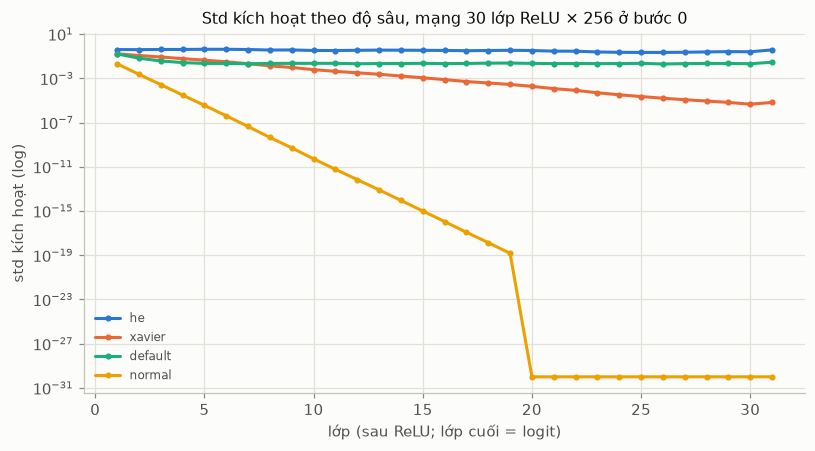

In [16]:
# (a) std kích hoạt (sau mỗi ReLU, và logit) + loss bước 0 của M-base, một lô val 4096 mẫu, seed 1
xb_val = data["X_val"][:4096]
rows = {}
for init in ("he", "xavier", "default", "normal", "zeros"):
    set_seed(1)
    m = MLP(hidden=(256, 128), init=init).to(device)
    st = activation_stats(m, xb_val)
    rows[init] = dict(std_h1=st[0], std_h2=st[1], std_logit=st[2], step0_loss=evaluate(m, data["X_val"], data["y_val"])["loss"])
display(pd.DataFrame(rows).T.round(5))

# (b) gradient bước 0 khi init = zeros: chỉ b3 khác 0
set_seed(1)
mz = MLP(hidden=(256, 128), init="zeros").to(device)
compute_loss(mz(data["X_tr"][:512]), data["y_tr"][:512], "ce").backward()
print("init=zeros, ‖grad‖ bước 0:", {n: f"{p.grad.norm().item():.2e}" for n, p in zip(["W1", "b1", "W2", "b2", "W3", "b3"], mz.parameters())})

# (c) mạng sâu 30 lớp ẩn × 256 (chỉ khởi tạo, không huấn luyện)
deep = {}
for init in ("he", "xavier", "default", "normal"):
    set_seed(1)
    deep[init] = activation_stats(MLP(hidden=(256,) * 30, init=init).to(device), xb_val)
plot_activation_depth(deep, f"{FIG_DIR}/compare_init_depth.png",
                      title="Std kích hoạt theo độ sâu, mạng 30 lớp ReLU × 256 ở bước 0")
print("std sau lớp 1 / 10 / 20 / 30:", {k: [f"{v[i]:.2e}" for i in (0, 9, 19, 29)] for k, v in deep.items()})
show(f"{FIG_DIR}/compare_init_depth.png")

init-zeros                 best ep   9/20  val_loss 1.2052  acc 0.4876  F1 0.0936  |g| 0.038  0.31s/ep


init-normal                best ep  18/20  val_loss 0.2148  acc 0.9153  F1 0.8653  |g| 0.355  0.31s/ep


init-xavier                best ep  20/20  val_loss 0.2187  acc 0.9124  F1 0.8534  |g| 0.355  0.31s/ep


init-default               best ep  20/20  val_loss 0.2206  acc 0.9127  F1 0.8638  |g| 0.350  0.31s/ep


,best_ep,step0,best_val_loss,gap_val_train,val_acc,val_F1,s_per_ep,diverged,ΔF1_vs_base,vượt 2σ?
exp_id,,,,,,,,,,
base-s1,20,2.2691,0.2261,0.0250,0.9098,0.8571,0.3090,False,-0.0020,Không
init-zeros,9,1.9459,1.2052,0.0000,0.4876,0.0936,0.3099,False,-0.7654,Có
init-normal,18,1.9460,0.2148,0.0265,0.9153,0.8653,0.3076,False,0.0062,Không
init-xavier,20,2.0222,0.2187,0.0245,0.9124,0.8534,0.3117,False,-0.0057,Không
init-default,20,1.9830,0.2206,0.0245,0.9127,0.8638,0.3088,False,0.0047,Không


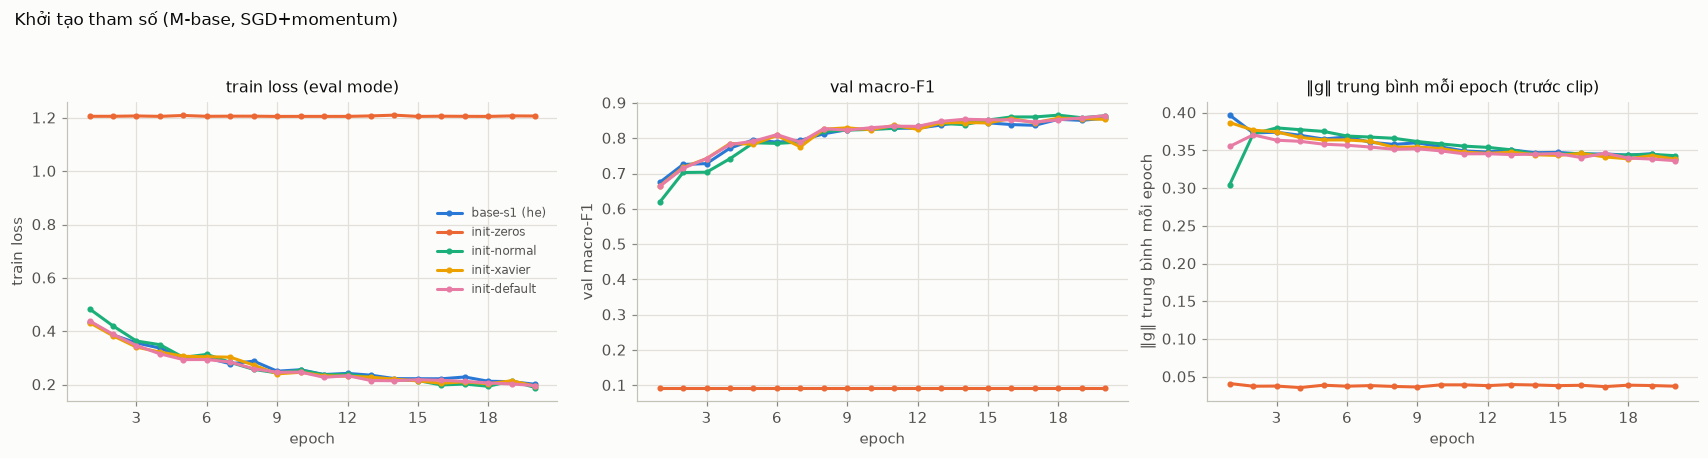

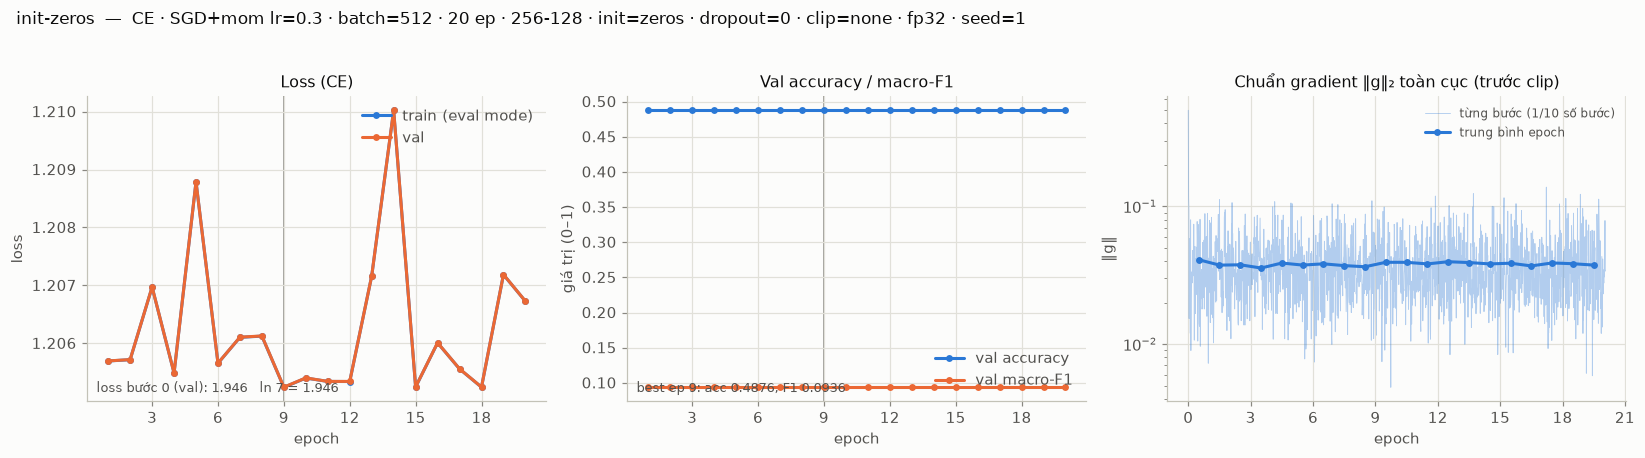

In [17]:
for init in ("zeros", "normal", "xavier", "default"):
    run(f"init-{init}", "init", f"khởi tạo {init}" + (" (mặc định nn.Linear, không phải He)" if init == "default" else ""), init=init)
init_ids = ["base-s1", "init-zeros", "init-normal", "init-xavier", "init-default"]
display(table(init_ids))
plot_compare([RESULTS[e] for e in init_ids], ["train_loss", "val_macro_f1", "grad_norm"], f"{FIG_DIR}/compare_init.png",
             title="Khởi tạo tham số (M-base, SGD+momentum)", labels=["base-s1 (he)"] + init_ids[1:])
show(f"{FIG_DIR}/compare_init.png")
show(f"{FIG_DIR}/init-zeros.png")

**Đối chiếu sau khi chạy:**
- **zeros: khớp dự đoán.** ‖grad‖ bước 0 bằng 0 ở W1, b1, W2, b2, W3; chỉ b3 có gradient (0,497). Sau 20 epoch mạng vẫn đoán toàn lớp 1: acc 0,4876, F1 0,094, val loss 1,206 = entropy của phân phối lớp. Mạng chỉ học được tần suất lớp qua b3. Nguyên nhân là đối xứng cộng với ReLU(0) = 0: gradient của W3 = (p−y)·h₂ᵀ = 0, gradient truyền ngược Wᵀ(p−y) = 0, nên không lớp ẩn nào nhận được tín hiệu.
- **Kích hoạt ở bước 0 (M-base):** std logit 0,58 (he) / 0,19 (xavier) / 0,06 (default) / 0,0003 (normal), nên loss bước 0 lần lượt 2,269 / 2,022 / 1,983 / 1,946, đúng thứ tự dự đoán.
- **F1 sau 20 epoch:** normal 0,8653, xavier 0,8534, default 0,8638, **đều trong nhiễu so với He** (|Δ| ≤ 0,007). Riêng normal **khác dự đoán** "chậm rõ": nó chỉ chậm ở epoch 1 (F1 0,619 so với 0,675 của He) rồi bắt kịp ngay từ epoch 3. Mạng chỉ 3 lớp nên tín hiệu teo còn 2·10⁻⁴ ở logit vẫn đủ để gradient lớp cuối khác 0, và SGD+momentum lr 0,3 khuếch đại trọng số rất nhanh. 3 lớp **không đủ sâu** để thấy khác biệt giữa các cách khởi tạo hợp lý.
- **Mạng 30 lớp** (`compare_init_depth.png`): He giữ std ~0,4 → 0,25 suốt 30 lớp; xavier giảm theo cấp số nhân (1,7·10⁻¹ → 4,6·10⁻⁶), vì với ReLU mỗi lớp nhân phương sai với n·2/(n_vào+n_ra)·½ = ½; normal(0,01) tắt hẳn (5·10⁻¹¹ ở lớp 10, bằng 0 sau lớp 20 do underflow FP32). Đúng hình "30 lớp ReLU" của slide. **Bất ngờ:** default chỉ giảm tới ~0,02 rồi đứng yên, vì bias của nó ngẫu nhiên U(±1/√n) chứ không bằng 0; bias bơm lại phương sai ở mỗi lớp, nên tín hiệu là của bias chứ không còn mang thông tin đầu vào.

### 3.8 Kết hợp: cấu hình cuối cùng (chọn **chỉ bằng val**, theo quy tắc viết trước)
Quy tắc (áp dụng tự động trên các số val ở trên, không nhìn eval):
1. **Bộ tối ưu + lr**: cấu hình có val macro-F1 cao nhất trong nhóm `optimizer` (gồm cả lr baseline).
2. **Kiến trúc**: dùng `M-wide` / `M-deep` nếu `hp-wide` / `hp-deep` hơn trung bình baseline **quá 2σ** (lấy cái tốt hơn); ngược lại giữ `M-base`.
3. **Số epoch**: 40 nếu `hp-ep40` hơn baseline quá 2σ. **Lịch lr**: cosine nếu `hp-cosine` hơn baseline quá 2σ.
4. **Dropout / clipping / khởi tạo / weight decay**: chỉ thêm nếu thí nghiệm tương ứng hơn baseline quá 2σ.
5. Giữ batch 512 (batch nhỏ có lợi chủ yếu nhờ thêm số bước, phần này lấy bằng cách tăng epoch mà không làm chậm từng epoch) và FP32 (mixed precision không nhằm tăng độ chính xác).

Cấu hình cuối chạy 3 seed (`final-s1..3`) để có độ nhiễu; file nộp là của **seed 1** (cố định từ trước, không chọn seed theo điểm).

**Dự đoán trước:** cấu hình cuối có val macro-F1 cao hơn baseline rất rõ (vài điểm phần trăm, vượt xa 2σ), nhờ bộ tối ưu thích nghi + mạng rộng hơn + nhiều bước hơn; lớp hiếm (3, 4, 5) là nơi cải thiện nhiều nhất.

In [18]:
def beats_base(e):
    return f1(e) - BASE_F1_MEAN > NOISE_F1

decisions = []
opt_group = [e for e, r in RESULTS.items() if r["cfg"]["group"] == "optimizer"]
best_opt = max(opt_group, key=f1)
oc = RESULTS[best_opt]["cfg"]
final_cfg = {**BASE_CFG, "optimizer": oc["optimizer"], "lr": oc["lr"], "weight_decay": oc["weight_decay"]}
decisions.append(f"bộ tối ưu: {best_opt} (val F1 {f1(best_opt):.4f})")

arch = [e for e in ("hp-wide", "hp-deep") if beats_base(e)]
if arch:
    e = max(arch, key=f1)
    final_cfg["hidden"] = RESULTS[e]["cfg"]["hidden"]
    decisions.append(f"kiến trúc: {e} (val F1 {f1(e):.4f})")
if beats_base("hp-ep40"):
    final_cfg["epochs"] = 40
    decisions.append(f"40 epoch (hp-ep40 val F1 {f1('hp-ep40'):.4f})")
if beats_base("hp-cosine"):
    final_cfg["scheduler"] = "cosine"
    decisions.append(f"lịch lr cosine (hp-cosine val F1 {f1('hp-cosine'):.4f})")
for e in [x for x in RESULTS if x.startswith("drop-")]:
    if beats_base(e) and f1(e) >= max(f1(x) for x in RESULTS if x.startswith("drop-")):
        final_cfg["dropout"] = RESULTS[e]["cfg"]["dropout"]
        decisions.append(f"dropout {final_cfg['dropout']} ({e})")
if beats_base(f"clip-{C_CLIP:g}"):
    final_cfg["clip_norm"] = C_CLIP
    decisions.append(f"clip c={C_CLIP:g}")
better_init = [e for e in ("init-normal", "init-xavier", "init-default") if beats_base(e)]
if better_init:
    e = max(better_init, key=f1)
    final_cfg["init"] = RESULTS[e]["cfg"]["init"]
    decisions.append(f"khởi tạo {final_cfg['init']} ({e})")
if final_cfg["optimizer"] in ("sgd", "sgd_momentum") and beats_base("hp-wd5e-4"):
    final_cfg["weight_decay"] = 5e-4
    decisions.append("weight decay 5e-4")

print(f"trung bình baseline {BASE_F1_MEAN:.4f}, 2σ = {NOISE_F1:.4f}; các thí nghiệm hơn baseline quá 2σ:")
print("  ", [e for e in RESULTS if RESULTS[e]["cfg"]["group"] not in ("baseline",) and beats_base(e)])
print("Quyết định:\n  - " + "\n  - ".join(decisions))
desc = "Cấu hình cuối: " + "; ".join(decisions)
print({k: final_cfg[k] for k in ("optimizer", "lr", "weight_decay", "hidden", "epochs", "scheduler", "dropout", "clip_norm", "init", "batch", "precision")})

trung bình baseline 0.8591, 2σ = 0.0202; các thí nghiệm hơn baseline quá 2σ:
   ['hp-cosine']
Quyết định:
  - bộ tối ưu: opt-adam-lr0.003 (val F1 0.8719)
  - lịch lr cosine (hp-cosine val F1 0.8885)
{'optimizer': 'adam', 'lr': 0.003, 'weight_decay': 0.0, 'hidden': (256, 128), 'epochs': 20, 'scheduler': 'cosine', 'dropout': 0.0, 'clip_norm': None, 'init': 'he', 'batch': 512, 'precision': 'fp32'}


  [final-s1] ep  1  train 0.4288  val 0.4324  acc 0.8188  F1 0.6687  |g| 0.612  0.5s


  [final-s1] ep  2  train 0.3698  val 0.3768  acc 0.8425  F1 0.7471  |g| 0.637  0.5s


  [final-s1] ep  3  train 0.3334  val 0.3417  acc 0.8584  F1 0.7543  |g| 0.649  0.5s


  [final-s1] ep  4  train 0.3032  val 0.3124  acc 0.8713  F1 0.7981  |g| 0.670  0.5s


  [final-s1] ep  5  train 0.2812  val 0.2934  acc 0.8802  F1 0.7983  |g| 0.661  0.5s


...

  [final-s1] ep 19  train 0.1659  val 0.1915  acc 0.9252  F1 0.8838  |g| 0.587  0.5s


  [final-s1] ep 20  train 0.1658  val 0.1912  acc 0.9254  F1 0.8839  |g| 0.575  0.5s
  => final-s1: step0 2.2691 | best ep 20 val_loss 0.1912 acc 0.9254 F1 0.8839 | 0.49s/ep
final-s1                   best ep  20/20  val_loss 0.1912  acc 0.9254  F1 0.8839  |g| 0.641  0.49s/ep


final-s2                   best ep  20/20  val_loss 0.1924  acc 0.9239  F1 0.8866  |g| 0.635  0.49s/ep


final-s3                   best ep  20/20  val_loss 0.1913  acc 0.9244  F1 0.8862  |g| 0.640  0.49s/ep

final val macro-F1 = 0.8856 ± 0.0015  vs baseline 0.8591 ± 0.0101


,best_ep,step0,best_val_loss,gap_val_train,val_acc,val_F1,s_per_ep,diverged,ΔF1_vs_base,vượt 2σ?
exp_id,,,,,,,,,,
base-s1,20,2.2691,0.2261,0.0250,0.9098,0.8571,0.3090,False,-0.0020,Không
base-s2,20,1.9782,0.2107,0.0236,0.9156,0.8704,0.3087,False,0.0113,Không
base-s3,20,1.9005,0.2183,0.0255,0.9144,0.8677,0.3075,False,0.0087,Không
base-s4,19,2.3106,0.2220,0.0251,0.9110,0.8547,0.3072,False,-0.0044,Không
base-s5,20,2.1444,0.2267,0.0245,0.9105,0.8455,0.3127,False,-0.0136,Không
final-s1,20,2.2691,0.1912,0.0254,0.9254,0.8839,0.4921,False,0.0248,Có
final-s2,20,1.9782,0.1924,0.0254,0.9239,0.8866,0.4916,False,0.0275,Có
final-s3,20,1.9005,0.1913,0.0256,0.9244,0.8862,0.4898,False,0.0271,Có


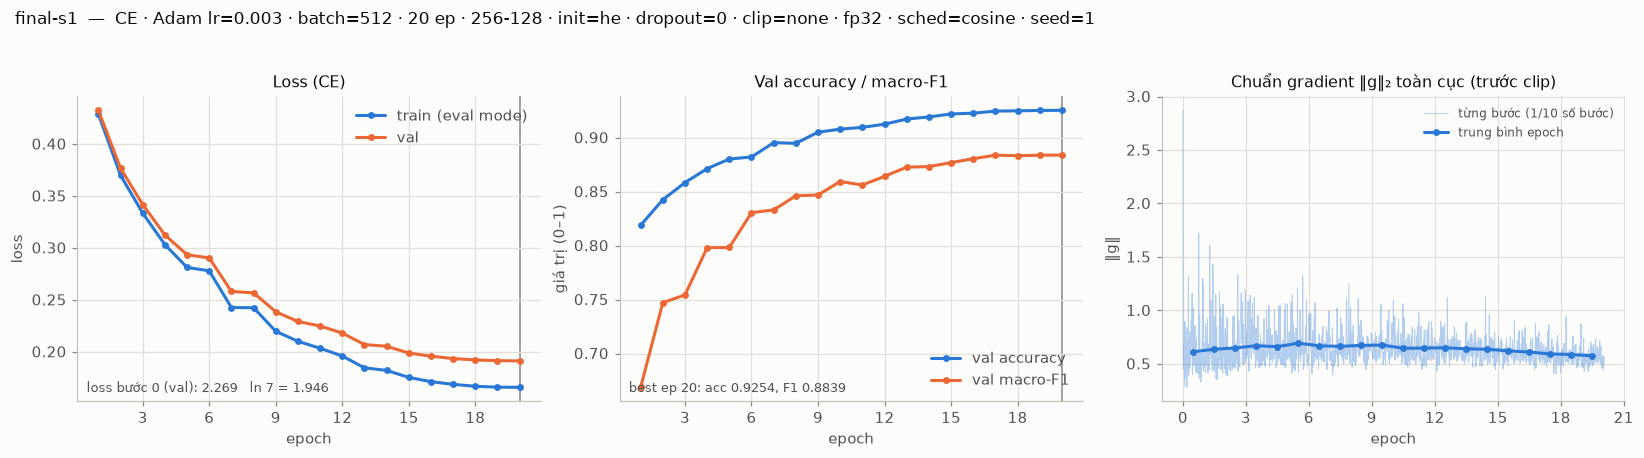

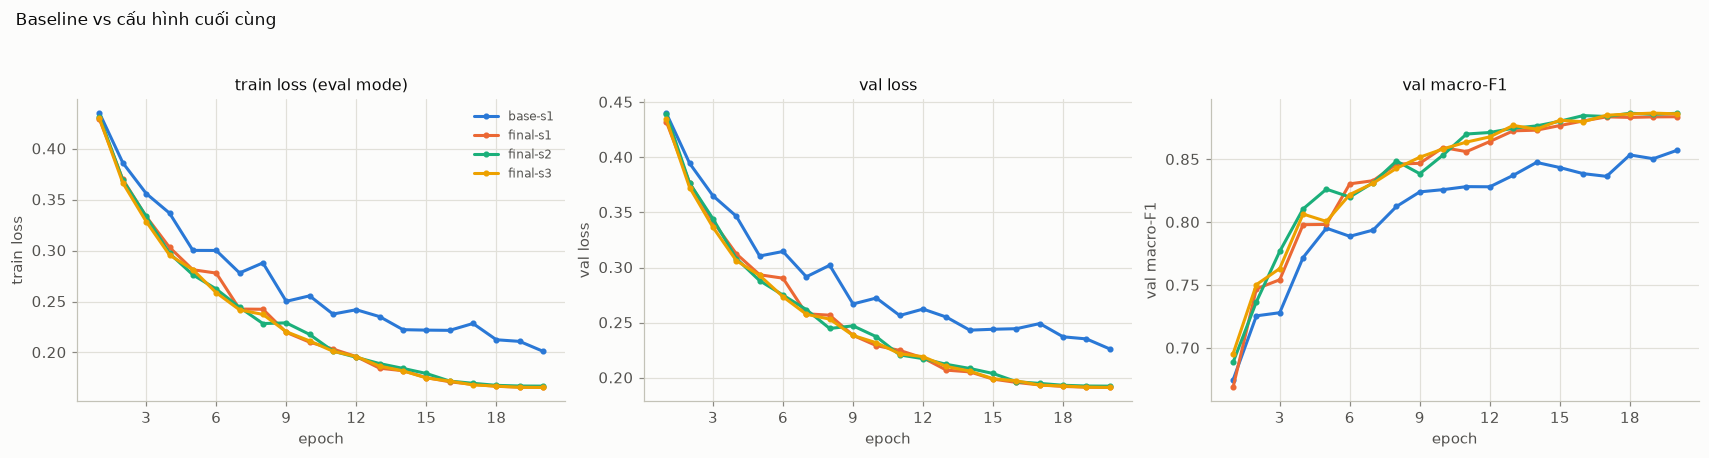

In [19]:
final_ids = []
for s in (1, 2, 3):
    run(f"final-s{s}", "final", desc + f"; seed {s}", base=final_cfg, seed=s, verbose=(s == 1),
        notes="nộp seed 1 (cố định trước)" if s == 1 else "")
    final_ids.append(f"final-s{s}")
FINAL_F1 = np.array([f1(e) for e in final_ids])
print(f"\nfinal val macro-F1 = {FINAL_F1.mean():.4f} ± {FINAL_F1.std(ddof=1):.4f}  vs baseline {BASE_F1_MEAN:.4f} ± {BASE_F1_STD:.4f}")
display(table(base_ids + final_ids))
plot_compare([RESULTS[e] for e in ["base-s1", "final-s1", "final-s2", "final-s3"]], ["train_loss", "val_loss", "val_macro_f1"],
             f"{FIG_DIR}/compare_final.png", title="Baseline vs cấu hình cuối cùng")
show(f"{FIG_DIR}/final-s1.png")
show(f"{FIG_DIR}/compare_final.png")

**Đối chiếu sau khi chạy:** quy tắc 3.8 chỉ giữ lại hai thành phần: **Adam lr 3e-3** (bộ tối ưu có val F1 cao nhất, dù chưa vượt 2σ so với SGD+momentum) và **lịch lr cosine** (thí nghiệm duy nhất hơn baseline quá 2σ). M-wide (+0,015) và 40 epoch (+0,017) bị loại vì chưa vượt 2σ. Cấu hình cuối: **val F1 = 0,8856 ± 0,0015** (3 seed), hơn trung bình baseline 0,8591 là **+0,027**, vượt 2σ của baseline (0,020); σ giữa các seed cũng nhỏ đi ~7 lần (0,0015 so với 0,0101) vì lr giảm về 0 ở cuối làm điểm dừng ít phụ thuộc vào vài bước cuối. Dự đoán "hơn baseline vài điểm phần trăm, vượt xa 2σ" **đúng hướng nhưng quá lạc quan về độ lớn**.
Điều cần nói thẳng: `hp-cosine` (SGD+momentum + cosine, 1 seed) đạt 0,8885, ngang cấu hình cuối, nên **lợi ích gần như hoàn toàn đến từ lịch lr cosine**; đổi sang Adam không thêm gì đo được (một seed của `hp-cosine` không đủ để phân định). Do chỉ chạy các thí nghiệm một yếu tố, mình không đo được tương tác (ví dụ M-wide + cosine + 40 epoch có thể tốt hơn).

## Part 4 — Đánh giá cuối trên eval, bảng và nộp bài
Chỉ hai mô hình chạm vào tập eval: `base-s1` (baseline) và `final-s1` (cấu hình cuối, chọn ở 3.8 chỉ bằng val). Mỗi mô hình nạp trọng số của **epoch có val loss thấp nhất**, dự đoán toàn bộ 116 203 mẫu eval ở chế độ `eval()` (FP32, không dropout), ghi CSV `row_id,pred`, rồi chạy đúng `scripts/evaluate.py`. Không có bước nào sau đây thay đổi cấu hình.

In [20]:
# Baseline: dự đoán riêng (không nộp), lưu trong results/
ev_base = final_eval(RESULTS["base-s1"]["cfg"], RESULTS["base-s1"], data, f"{RES_DIR}/eval_baseline_predictions.csv",
                     repo_root=REPO_ROOT, out_json=f"{RES_DIR}/eval_baseline_result.json")

đã ghi ../results/eval_baseline_predictions.csv (116,203 dòng) từ base-s1, epoch 20


n_eval = 116203
accuracy = 0.9089
macro_f1 = 0.8586   <- chỉ số chính

lớp  support  precision  recall    f1
  0    42368     0.9154  0.8994  0.9073
  1    56661     0.9183  0.9295  0.9239
  2     7151     0.9041  0.8832  0.8935
  3      549     0.8234  0.7814  0.8019
  4     1899     0.7862  0.7514  0.7684
  5     3473     0.7940  0.8100  0.8019
  6     4102     0.8870  0.9417  0.9136

ma trận nhầm lẫn (hàng = thật, cột = dự đoán):
       0      1     2    3     4     5     6
0  38105   3776     3    0    37     6   441
1   3278  52668   132    0   327   205    51
2      1    275  6316   69    20   470     0
3      0      7    72  429     0    41     0
4     28    409    27    0  1427     8     0
5     11    186   436   23     4  2813     0
6    204     35     0    0     0     0  3863

đã ghi /Users/admin/Desktop/K4-Track4-Day1-Neuralnetwork/submission_2A202602515/results/eval_baseline_result.json



In [21]:
# Cấu hình cuối cùng (seed 1): file nộp predictions_eval.csv + eval_result.json
ev_final = final_eval(RESULTS["final-s1"]["cfg"], RESULTS["final-s1"], data, f"{OUT_DIR}/predictions_eval.csv",
                      repo_root=REPO_ROOT, out_json=f"{OUT_DIR}/eval_result.json")
EVAL = {"base-s1": ev_base, "final-s1": ev_final}
cmp = pd.DataFrame({e: dict(val_acc=RESULTS[e]["summary"]["val_acc"], val_macro_f1=f1(e),
                            eval_acc=EVAL[e]["accuracy"], eval_macro_f1=EVAL[e]["macro_f1"]) for e in EVAL}).T
cmp["eval − val (F1)"] = cmp["eval_macro_f1"] - cmp["val_macro_f1"]
display(cmp.round(4))
print(f"cải thiện eval macro-F1 (final-s1 − base-s1) = {ev_final['macro_f1'] - ev_base['macro_f1']:+.4f}; "
      f"nhiễu seed trên val: 2σ_baseline = {NOISE_F1:.4f}, 2σ_final = {2 * FINAL_F1.std(ddof=1):.4f}")

đã ghi ../predictions_eval.csv (116,203 dòng) từ final-s1, epoch 20


n_eval = 116203
accuracy = 0.9238
macro_f1 = 0.8868   <- chỉ số chính

lớp  support  precision  recall    f1
  0    42368     0.9266  0.9133  0.9199
  1    56661     0.9281  0.9426  0.9353
  2     7151     0.9135  0.9245  0.9190
  3      549     0.8664  0.8033  0.8336
  4     1899     0.8684  0.7751  0.8191
  5     3473     0.8502  0.8336  0.8418
  6     4102     0.9447  0.9327  0.9387

ma trận nhầm lẫn (hàng = thật, cột = dự đoán):
       0      1     2    3     4     5     6
0  38694   3435     0    0    32    10   197
1   2761  53407   150    0   181   135    27
2      2    165  6611   44     8   321     0
3      0      2    74  441     0    32     0
4     46    349    20    0  1472    12     0
5     10    161   382   24     1  2895     0
6    248     27     0    0     1     0  3826

đã ghi /Users/admin/Desktop/K4-Track4-Day1-Neuralnetwork/submission_2A202602515/eval_result.json



,val_acc,val_macro_f1,eval_acc,eval_macro_f1,eval − val (F1)
base-s1,0.9098,0.8571,0.9089,0.8586,0.0016
final-s1,0.9254,0.8839,0.9238,0.8868,0.0029


cải thiện eval macro-F1 (final-s1 − base-s1) = +0.0281; nhiễu seed trên val: 2σ_baseline = 0.0202, 2σ_final = 0.0030


,loại rừng,support,precision,recall,f1,F1 baseline,số mẫu train (X_tr)
cls,,,,,,,
0,Spruce/Fir,42368,0.9266,0.9133,0.9199,0.9073,135578
1,Lodgepole Pine,56661,0.9281,0.9426,0.9353,0.9239,181312
2,Ponderosa Pine,7151,0.9135,0.9245,0.9190,0.8935,22882
3,Cottonwood/Willow,549,0.8664,0.8033,0.8336,0.8019,1759
4,Aspen,1899,0.8684,0.7751,0.8191,0.7684,6075
5,Douglas-fir,3473,0.8502,0.8336,0.8418,0.8019,11115
6,Krummholz,4102,0.9447,0.9327,0.9387,0.9136,13126


,đoán 0,đoán 1,đoán 2,đoán 3,đoán 4,đoán 5,đoán 6
thật 0,38694,3435,0,0,32,10,197
thật 1,2761,53407,150,0,181,135,27
thật 2,2,165,6611,44,8,321,0
thật 3,0,2,74,441,0,32,0
thật 4,46,349,20,0,1472,12,0
thật 5,10,161,382,24,1,2895,0
thật 6,248,27,0,0,1,0,3826


lớp 0 (Spruce/Fir       ) recall 0.913; nhầm nhiều nhất sang lớp 1 (Lodgepole Pine): 8.1% (3435 mẫu)
lớp 1 (Lodgepole Pine   ) recall 0.943; nhầm nhiều nhất sang lớp 0 (Spruce/Fir): 4.9% (2761 mẫu)
lớp 2 (Ponderosa Pine   ) recall 0.924; nhầm nhiều nhất sang lớp 5 (Douglas-fir): 4.5% (321 mẫu)
lớp 3 (Cottonwood/Willow) recall 0.803; nhầm nhiều nhất sang lớp 2 (Ponderosa Pine): 13.5% (74 mẫu)
lớp 4 (Aspen            ) recall 0.775; nhầm nhiều nhất sang lớp 1 (Lodgepole Pine): 18.4% (349 mẫu)
lớp 5 (Douglas-fir      ) recall 0.834; nhầm nhiều nhất sang lớp 2 (Ponderosa Pine): 11.0% (382 mẫu)
lớp 6 (Krummholz        ) recall 0.933; nhầm nhiều nhất sang lớp 0 (Spruce/Fir): 6.0% (248 mẫu)


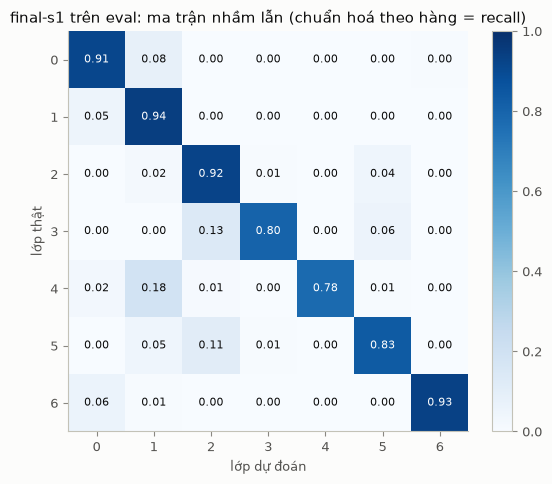

In [22]:
# Phân tích lỗi theo lớp (eval): precision / recall / F1 + ma trận nhầm lẫn
NAMES = ["Spruce/Fir", "Lodgepole Pine", "Ponderosa Pine", "Cottonwood/Willow", "Aspen", "Douglas-fir", "Krummholz"]
pc = pd.DataFrame(ev_final["per_class"]).set_index("cls")
pc.insert(0, "loại rừng", NAMES)
pc["F1 baseline"] = [c["f1"] for c in ev_base["per_class"]]
pc["số mẫu train (X_tr)"] = data["class_counts_tr"]
display(pc.round(4))
cm = np.array(ev_final["confusion_matrix"])
cm_df = pd.DataFrame(cm, index=[f"thật {c}" for c in range(7)], columns=[f"đoán {c}" for c in range(7)])
display(cm_df)
row_norm = cm / cm.sum(1, keepdims=True)
for c in range(7):
    off = row_norm[c].copy(); off[c] = 0
    j = off.argmax()
    print(f"lớp {c} ({NAMES[c]:<17s}) recall {row_norm[c, c]:.3f}; nhầm nhiều nhất sang lớp {j} ({NAMES[j]}): {100 * off[j]:.1f}% ({cm[c, j]} mẫu)")

with plt.rc_context(STYLE):
    fig, ax = plt.subplots(figsize=(6.2, 5.2))
    im = ax.imshow(row_norm, cmap="Blues", vmin=0, vmax=1)
    for i in range(7):
        for j in range(7):
            ax.text(j, i, f"{row_norm[i, j]:.2f}", ha="center", va="center", fontsize=8,
                    color="white" if row_norm[i, j] > 0.6 else "#0b0b0b")
    ax.set(xticks=range(7), yticks=range(7), xlabel="lớp dự đoán", ylabel="lớp thật",
           title="final-s1 trên eval: ma trận nhầm lẫn (chuẩn hoá theo hàng = recall)")
    ax.grid(False)
    fig.colorbar(im, ax=ax, fraction=0.046)
    plt.show()

In [23]:
# Lý giải bằng dữ liệu (chỉ dùng X_tr, đơn vị gốc): độ cao và vùng hoang dã theo lớp
Xtr = data["X_tr"].cpu().numpy(); ytr = data["y_tr"].cpu().numpy()
elev = Xtr[:, 0] * data["std"][0] + data["mean"][0]
rows = {}
for c in range(7):
    m = ytr == c
    wa = Xtr[m, 10:14].mean(0)
    rows[c] = {"loại rừng": NAMES[c], "n": int(m.sum()), "Elevation p10": np.percentile(elev[m], 10), "Elevation median": np.median(elev[m]),
               "Elevation p90": np.percentile(elev[m], 90), **{f"Wilderness_{k}": wa[k] for k in range(4)}}
display(pd.DataFrame(rows).T.round(2))

,loại rừng,n,Elevation p10,Elevation median,Elevation p90,Wilderness_0,Wilderness_1,Wilderness_2,Wilderness_3
0,Spruce/Fir,135578,2924.699951,3146.0,3311.0,0.498702,0.087499,0.413799,0.0
1,Lodgepole Pine,181312,2664.0,2936.0,3165.0,0.515785,0.031939,0.441692,0.010584
2,Ponderosa Pine,22882,2112.0,2403.0,2639.0,0.0,0.0,0.398173,0.601827
3,Cottonwood/Willow,1759,2079.800049,2231.0,2350.0,0.0,0.0,0.0,1.0
4,Aspen,6075,2674.399902,2797.0,2904.0,0.394733,0.0,0.605267,0.0
5,Douglas-fir,11115,2149.0,2426.0,2657.0,0.0,0.0,0.436257,0.563743
6,Krummholz,13126,3243.0,3363.0,3459.0,0.244705,0.112601,0.642694,0.0


**Phân tích lỗi:** (eval, `final-s1`; số từ `eval_result.json`)
- **Lớp khó nhất là lớp 4 (Aspen), F1 = 0,819** (precision 0,868, recall **0,775**). Nó bị nhầm nhiều nhất sang **lớp 1 (Lodgepole Pine): 349/1 899 mẫu = 18,4%**. Lý do: (i) ít dữ liệu, chỉ 6 075 mẫu train (1,6%) so với 181 312 của lớp 1, nên ranh giới bị kéo về phía lớp đông; (ii) đặc trưng chồng lấn: độ cao của Aspen (p10–p90: 2 674–2 904 m) nằm gọn trong khoảng của Lodgepole (2 664–3 165 m), và cả hai cùng xuất hiện ở vùng hoang dã 0 và 2.
- **Lớp 3 (Cottonwood/Willow), F1 = 0,834:** recall 0,803, nhầm sang lớp 2 (Ponderosa Pine) 13,5%. Lớp 3 chỉ có 1 759 mẫu train và chỉ xuất hiện ở vùng hoang dã 3, đúng nơi 60% mẫu Ponderosa sống; độ cao 2 080–2 350 m nằm trong khoảng 2 112–2 639 m của Ponderosa.
- **Lớp 5 (Douglas-fir), F1 = 0,842:** nhầm sang lớp 2 tới 11,0%, và ngược lại lớp 2 nhầm sang 5 là 4,5%. Hai lớp gần như trùng nhau về độ cao (2 149–2 657 so với 2 112–2 639 m) và phân bố vùng hoang dã (2/3).
- **Lớp 0 ↔ 1** có số mẫu nhầm tuyệt đối lớn nhất (3 435 và 2 761) do vùng độ cao 2 925–3 165 m chồng lấn, nhưng vì hai lớp rất đông nên F1 vẫn > 0,92.
- So với baseline, cấu hình cuối cải thiện F1 ở **mọi** lớp, nhiều nhất ở lớp hiếm: lớp 4 +0,051, lớp 5 +0,040, lớp 3 +0,032.
- Cách cải thiện mình sẽ thử: trọng số lớp trong CE (ví dụ ∝ 1/√tần suất) hoặc lấy mẫu cân bằng hơn cho lớp 3/4/5, chọn bằng val macro-F1; huấn luyện lâu hơn với mạng rộng hơn (val loss của `hp-wide` thấp hơn rõ).

Nhận xét ngắn cho sheet `Summary` (mỗi nhóm một câu; số liệu lấy trực tiếp từ kết quả val ở trên):

In [24]:
def SUMMARY_NOTES_TEXT(g):
    # Nhận xét cho sheet Summary, sinh từ chính các số val ở trên (không gõ tay số liệu).
    R, f = g["RESULTS"], g["f1"]
    m, n2 = g["BASE_F1_MEAN"], g["NOISE_F1"]
    d = lambda e: f"{e}: F1 {f(e):.4f} ({f(e) - m:+.4f}{', vượt 2σ' if abs(f(e) - m) > n2 else ', trong nhiễu'})"
    best_of, C = g["best_of"], g["C_CLIP"]
    xw = {e: R[e]["summary"]["time_per_epoch_s"] for e in g["xw_ids"]}
    amp = {e: R[e]["summary"]["time_per_epoch_s"] for e in g["amp_ids"]}
    return {
        "baseline": f"5 seed, SGD+momentum lr={g['BASE_LR']:g}: val F1 {m:.4f} ± {g['BASE_F1_STD']:.4f} (2σ = {n2:.4f}); "
                    f"val acc {g['BASE_ACC_MEAN']:.4f} > 0.4876 (đoán đa số).",
        "loss": f"{d('loss-mse')}; {d(g['loss_ids'][2])}. So bằng acc/F1, không so loss.",
        "optimizer": "lr tốt nhất mỗi bộ: " + "; ".join(f"{k} lr={R[e]['cfg']['lr']:g} F1 {f(e):.4f}" for k, e in best_of.items())
                     + f". AdamW wd=0 trùng Adam (max|Δval_loss| {g['diff']:.1e}).",
        "hparam": "; ".join(d(e) for e in g["hp_ids"]) + ".",
        "dropout": "; ".join(d(e) for e in ("drop-0.1", "drop-0.3", "drop-0.5")) + ". Baseline chưa quá khớp.",
        "clipping": f"c={C:g} (trung vị ‖g‖): {d(f'clip-{C:g}')}; " + "; ".join(
                    f"lr={h:g}: không clip F1 {f(f'clip-none-lr{h:g}'):.4f}, có clip F1 {f(f'clip-{C:g}-lr{h:g}'):.4f}"
                    for h in g["LR_HIGHS"]) + ".",
        "amp": "s/epoch M-base: " + ", ".join(f"{e} {t:.2f}" for e, t in amp.items())
               + "; 2048-2048: " + ", ".join(f"{e[10:]} {t:.2f}" for e, t in xw.items()) + ". F1 M-base: "
               + ", ".join(f"{e} {f(e):.4f}" for e in g["amp_ids"]) + ".",
        "init": "; ".join(d(e) for e in ("init-zeros", "init-normal", "init-xavier", "init-default")) + ".",
        "final": f"{g['desc']}. Val F1 3 seed {g['FINAL_F1'].mean():.4f} ± {g['FINAL_F1'].std(ddof=1):.4f} (baseline {m:.4f}).",
    }

In [25]:
# Bảng experiments.xlsx từ mẫu (đọc lại từ results/*.json để bảng khớp đúng file kết quả)
GROUP_ORDER = ["baseline", "loss", "optimizer", "hparam", "dropout", "clipping", "amp", "init", "final"]
results = load_results(RES_DIR)
order = {e: i for i, e in enumerate(RESULTS)}            # thứ tự chạy trong notebook
results = sorted(results, key=lambda r: (GROUP_ORDER.index(r["cfg"]["group"]), order.get(r["cfg"]["exp_id"], 999)))
assert {r["cfg"]["exp_id"] for r in results} == set(RESULTS), "results/ phải khớp đúng các lần chạy trong notebook"
rows = [to_row(r, eval_scores=EVAL.get(r["cfg"]["exp_id"])) for r in results]
if device == "mps":
    for row in rows:
        row["notes"] = "; ".join(x for x in (row["notes"], f"peak_mem trên MPS: lấy mẫu sau forward, gồm {DATA_MB:.0f} MB dữ liệu") if x)
SUMMARY_NOTES = SUMMARY_NOTES_TEXT(globals())
write_xlsx(rows, f"{REPO_ROOT}/templates/experiment_table_template.xlsx", f"{OUT_DIR}/experiments.xlsx",
           seeds=base_ids, summary_notes=SUMMARY_NOTES)
figs = sorted(f[:-4] for f in os.listdir(FIG_DIR) if f.endswith(".png") and not f.startswith("compare_"))
assert figs == sorted(r["exp_id"] for r in rows), "mỗi dòng của bảng phải có đúng một ảnh figures/<exp_id>.png"
print(f"experiments.xlsx: {len(rows)} dòng; {len(figs)} ảnh thí nghiệm + "
      f"{sum(f.startswith('compare_') for f in os.listdir(FIG_DIR))} ảnh compare_*; tổng thời gian notebook {(time.time() - T_NOTEBOOK) / 60:.1f} phút")
display(pd.DataFrame(rows).set_index("exp_id")[["group", "optimizer", "lr", "batch", "epochs", "hidden", "best_epoch",
                                                 "val_acc", "val_macro_f1", "eval_acc", "eval_macro_f1"]])

experiments.xlsx: 52 dòng; 52 ảnh thí nghiệm + 14 ảnh compare_*; tổng thời gian notebook 12.8 phút


,group,optimizer,lr,batch,epochs,hidden,best_epoch,val_acc,val_macro_f1,eval_acc,eval_macro_f1
exp_id,,,,,,,,,,,
base-s1,baseline,SGD+momentum,0.3000,512,20,256-128,20,0.909759,0.857084,0.908935,0.858640
base-s2,baseline,SGD+momentum,0.3000,512,20,256-128,20,0.915589,0.870422,NaN,NaN
base-s3,baseline,SGD+momentum,0.3000,512,20,256-128,20,0.914352,0.867749,NaN,NaN
base-s4,baseline,SGD+momentum,0.3000,512,20,256-128,19,0.910996,0.854699,NaN,NaN
base-s5,baseline,SGD+momentum,0.3000,512,20,256-128,20,0.910544,0.845529,NaN,NaN
loss-mse,loss,SGD+momentum,0.3000,512,20,256-128,20,0.883350,0.784314,NaN,NaN
loss-mse-lr0.9,loss,SGD+momentum,0.9000,512,20,256-128,20,0.851100,0.687851,NaN,NaN
opt-sgdm-lr0.01,optimizer,SGD+momentum,0.0100,512,20,256-128,19,0.872098,0.764414,NaN,NaN
opt-sgdm-lr0.03,optimizer,SGD+momentum,0.0300,512,20,256-128,20,0.896108,0.828015,NaN,NaN
